# 01 — Analyse Exploratoire des Données (EDA)
# Dataset IST — International Stroke Trial

**Projet :** Stroke Prediction AI — IST Dataset  
**Notebook :** 01 — EDA (Exploratory Data Analysis)  
**Dataset :** `IST_corrected.csv` — 19 435 patients · 112 variables  
**Auteur :** ML_Project 2025-2026

---

## Rôle de ce notebook dans le pipeline

Ce notebook est le **point de départ absolu** du projet.  
Il n'entraîne aucun modèle. Il ne transforme pas les données.  
Son seul objectif : **comprendre le dataset avant de toucher quoi que ce soit**.

```
01_EDA.ipynb          ← ce notebook
    ↓ produit → features.json (liste des variables sélectionnées)
02_Preprocessing.ipynb
    ↓ produit → artefacts (X_train, X_test, preprocessor.pkl, ...)
03_Modeling.ipynb
    ↓ produit → modèle final (.pkl) + métriques
```

## Plan de ce notebook

| Section | Contenu |
|---------|---------|
| **1** | Configuration du projet — `config.py`, chemins, imports |
| **2** | Chargement et première lecture du dataset |
| **3** | Dictionnaire métier — classification temporelle des variables |
| **4** | Analyse des valeurs manquantes — volume, types, stratégie |
| **5** | Qualité des données — doublons, valeurs aberrantes, codes spéciaux |
| **6** | Variables numériques — distributions, outliers, valeurs à 0 |
| **7** | Variables catégorielles — fréquences, modalités, cohérence |
| **8** | Analyse des RDEF — taux de "C", impact sur le score de sévérité |
| **9** | Construction exploratoire de la cible `severity_class` |
| **10** | Analyse clinique croisée — sévérité vs variables clés |
| **11** | Corrélations et redondance — multicolinéarité, leakage |
| **12** | Détection du Data Leakage — liste des variables interdites |
| **13** | Sauvegarde `features.json` — pont vers le notebook 02 |
| **14** | Synthèse et recommandations pour le preprocessing |

---


---
## Section 1 — Configuration du projet

### 1.1 Pourquoi une configuration centralisée dès l'EDA ?

Le fichier `config.py` est le **chef d'orchestre** de tout le pipeline.  
Le charger dès l'EDA garantit que :

- les chemins vers les données sont identiques dans tous les notebooks,
- la graine aléatoire (`RANDOM_STATE = 42`) est cohérente de bout en bout,
- la fonction `save_features()` permet de **transmettre les variables sélectionnées**  
  en EDA directement au notebook de preprocessing via `features.json`.

### 1.2 Ce que fait `config.py`

```python
DATA_PATH     = PROJECT_ROOT / "Data" / "IST_corrected.csv"
RANDOM_STATE  = 42
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

def save_features(target, cat_vars, num_vars, all_features)  # → features.json
def load_features()                                           # ← features.json
def check_data_quality(df)                                    # vérification rapide
def ensure_directories()                                      # crée les dossiers
```


In [1]:
# ============================================================
# 1.1 — Imports standards
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import sys
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Style global des graphiques
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "xtick.labelsize": 10,
                     "ytick.labelsize": 10})

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:.3f}".format)

print("Imports chargés")


Imports chargés


In [2]:
# ============================================================
# 1.2 — Montage Google Drive + config centralisée
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

# Racine du projet — adapter si nécessaire
PROJECT_ROOT = Path("/content/drive/MyDrive/ML_Project")
SRC_PATH     = PROJECT_ROOT / "src"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

# Ajout de src/ au PATH Python
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Import et rechargement de config.py
import importlib
import config
importlib.reload(config)

from config import (
    DATA_PATH,
    RANDOM_STATE,
    save_features,      # sauvegarde features.json → utilisé par notebook 02
    load_features,
    check_data_quality,
    ensure_directories,
)

ensure_directories()

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"DATA_PATH     : {DATA_PATH}")
print(f"RANDOM_STATE  : {RANDOM_STATE}")
print(f"ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print()
print("Configuration chargée")


Mounted at /content/drive
PROJECT_ROOT  : /content/drive/MyDrive/ML_Project
DATA_PATH     : /content/drive/MyDrive/ML_Project/Data/IST_corrected.csv
RANDOM_STATE  : 42
ARTIFACTS_DIR : /content/drive/MyDrive/ML_Project/artifacts

Configuration chargée


---
## Section 2 — Chargement et première lecture du dataset

### 2.1 Contexte de l'IST

L'**International Stroke Trial** (IST) est l'un des plus grands essais cliniques  
jamais menés sur l'AVC aigu (1991–1996). Il a randomisé **19 435 patients**  
dans 467 hôpitaux, 36 pays, pour tester aspirine vs héparine.

Ce dataset est précieux pour le ML car :
- il couvre l'admission, 14 jours et 6 mois post-AVC,
- il est 100% complet au baseline et >99% complet au suivi,
- il est entièrement anonymisé et en accès libre.

### 2.2 Encodage latin1

Le fichier contient des caractères cliniques d'origine européenne.  
`encoding='latin1'` est obligatoire pour éviter les erreurs de lecture.


In [3]:
# ============================================================
# 2.1 — Chargement du dataset brut
# ============================================================

df = pd.read_csv(DATA_PATH, encoding="latin1", low_memory=False)

print("=" * 55)
print("VUE D'ENSEMBLE DU DATASET IST")
print("=" * 55)
print(f"  Lignes (patients)  : {df.shape[0]:,}")
print(f"  Colonnes (variables): {df.shape[1]}")
print(f"  Mémoire totale     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print()

# Répartition des types
type_counts = df.dtypes.value_counts()
print("Répartition des types de variables :")
for dtype, count in type_counts.items():
    print(f"  {str(dtype):10s} : {count} colonnes")

print()
print("Vérification rapide :")
check_data_quality(df)


VUE D'ENSEMBLE DU DATASET IST
  Lignes (patients)  : 19,435
  Colonnes (variables): 112
  Mémoire totale     : 66.0 MB

Répartition des types de variables :
  object     : 63 colonnes
  int64      : 29 colonnes
  float64    : 20 colonnes

Vérification rapide :
📊 DATA QUALITY REPORT

🔎 Valeurs manquantes totales : 379257

Colonnes avec valeurs manquantes :
FLASTD      19377
DRSHD       19338
DPED        19310
DMAJNCHX    19290
DMAJNCHD    19286
DDEADX      19267
DRSUNKD     19175
DRSISCD     19022
DNOSTRKX    19008
DSIDED      18802
DSIDEX      18797
FDEADX      18651
DHH14       18451
NCCODE      17916
DDEADD      17401
DDEADC      17101
FDEADD      15089
FDEADC      15071
DPLACE       9709
DALIVED      9113
FOAC         4574
FAP          4568
FPLACE       4502
FDENNIS      4499
FRECOVER     4420
DRSUNK       1007
DMH14        1006
DCAREND      1005
RATRIAL       984
RASP3         984
FU1_COMP      470
RHEP24        344
DTHROMB       315
DIVH          305
DSCH          305
DASPLT      

np.False_

In [4]:
# ============================================================
# 2.2 — Aperçu des premières lignes
# ============================================================

print("5 premières lignes — colonnes sélectionnées (baseline clinique) :")
cols_preview = ["HOSPNUM", "AGE", "SEX", "RCONSC", "RSBP", "RDELAY",
                "STYPE", "RDEF1", "RDEF2", "RDEF3", "RATRIAL"]
display(df[[c for c in cols_preview if c in df.columns]].head(5))


5 premières lignes — colonnes sélectionnées (baseline clinique) :


,HOSPNUM,AGE,SEX,RCONSC,RSBP,RDELAY,STYPE,RDEF1,RDEF2,RDEF3,RATRIAL
0,1,69,M,D,140,17,PACS,N,N,N,NaN
1,1,76,M,F,150,10,LACS,Y,Y,Y,NaN
2,1,71,F,F,170,43,LACS,Y,Y,Y,NaN
3,1,81,M,F,170,6,PACS,N,N,N,NaN
4,4,78,M,F,170,20,LACS,Y,Y,Y,NaN


In [5]:
# ============================================================
# 2.3 — Séparation variables numériques / catégorielles
# ============================================================

numeric_cols     = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Variables NUMÉRIQUES   : {len(numeric_cols)}")
print(f"Variables CATÉGORIELLES: {len(categorical_cols)}")
print()
print("Numériques :")
print(numeric_cols)
print()
print("Catégorielles :")
print(categorical_cols)


Variables NUMÉRIQUES   : 49
Variables CATÉGORIELLES: 63

Numériques :
['HOSPNUM', 'RDELAY', 'AGE', 'RSBP', 'HOURLOCAL', 'MINLOCAL', 'DAYLOCAL', 'ONDRUG', 'DMAJNCHD', 'DSIDED', 'DRSISCD', 'DRSHD', 'DRSUNKD', 'DPED', 'DALIVED', 'DDEADD', 'DDEADC', 'FLASTD', 'FDEADD', 'FDEADC', 'FU1_RECD', 'FU2_DONE', 'CNTRYNUM', 'FU1_COMP', 'DIED', 'TD', 'EXPDD', 'EXPD6', 'EXPD14', 'SET14D', 'ID14', 'OCCODE', 'DEAD1', 'DEAD2', 'DEAD3', 'DEAD4', 'DEAD5', 'DEAD6', 'DEAD7', 'DEAD8', 'H14', 'ISC14', 'NK14', 'STRK14', 'HTI14', 'PE14', 'DVT14', 'TRAN14', 'NCB14']

Catégorielles :
['RCONSC', 'SEX', 'RSLEEP', 'RATRIAL', 'RCT', 'RVISINF', 'RHEP24', 'RASP3', 'RDEF1', 'RDEF2', 'RDEF3', 'RDEF4', 'RDEF5', 'RDEF6', 'RDEF7', 'RDEF8', 'STYPE', 'RDATE', 'RXASP', 'RXHEP', 'DASP14', 'DASPLT', 'DLH14', 'DMH14', 'DHH14', 'DSCH', 'DIVH', 'DAP', 'DOAC', 'DGORM', 'DSTER', 'DCAA', 'DHAEMD', 'DCAREND', 'DTHROMB', 'DMAJNCH', 'DMAJNCHX', 'DSIDE', 'DSIDEX', 'DDIAGISC', 'DDIAGHA', 'DDIAGUN', 'DNOSTRK', 'DNOSTRKX', 'DRSISC', 'DRSH', '

---
## Section 3 — Dictionnaire métier et classification temporelle des variables

### 3.1 Pourquoi classifier les variables par temps de collecte ?

Le dataset IST collecte des informations à **3 moments distincts** :

```
T=0 (Admission)          T=14j (Discharge/Décès)      T=6mois (Suivi postal)
─────────────────        ─────────────────────────     ─────────────────────
AGE, SEX, RCONSC         DDEAD, DRSISC, DMAJNCH        FDEAD, FRECOVER
RDELAY, RSBP             DCAREND, DTHROMB              OCCODE, FPLACE
RDEF1..RDEF8             DSCH, DAP, DOAC               FAP, FOAC
STYPE, RATRIAL           DPLACE, DALIVE                FDENNIS
RCT, RVISINF             ...                           ...
```

**Règle d'or anti-leakage :**  
Pour l'**Axe 2** (sévérité à l'admission), on n'utilise que les variables de T=0.  
Utiliser des variables T=14j ou T=6mois pour prédire la sévérité à l'admission  
reviendrait à "regarder dans le futur" → performances artificiellement élevées.

### 3.2 Variables à usage restreint par axe

| Variable | Disponible | Utilisable pour |
|----------|-----------|-----------------|
| `RCONSC`, `RDEF1..8`, `STYPE` | T=0 | Axe 2 (avec précaution — construction cible) |
| `AGE`, `SEX`, `RSBP`, `RDELAY` | T=0 | Axes 2, 3, 4 |
| `DDEAD`, `DMAJNCH` | T=14j | Axe 3 uniquement (target) |
| `FDEAD`, `OCCODE` | T=6mois | Axes 3 et 4 (target) |
| `EXPDD`, `EXPD6`, `EXPD14` | Dérivées | !!! Leakage potentiel — à exclure |


In [6]:
# ============================================================
# 3.1 — Classification temporelle des variables
# ============================================================

# Classification selon le moment de collecte dans l'essai IST
var_groups = {
    "ADMISSION (T=0) — Baseline clinique": [
        "HOSPNUM", "RDELAY", "RCONSC", "SEX", "AGE", "RSLEEP",
        "RATRIAL", "RCT", "RVISINF", "RHEP24", "RASP3", "RSBP",
        "RDEF1", "RDEF2", "RDEF3", "RDEF4", "RDEF5", "RDEF6", "RDEF7", "RDEF8",
        "STYPE", "RDATE", "HOURLOCAL", "MINLOCAL", "DAYLOCAL",
        "RXASP", "RXHEP"
    ],
    "TRAITEMENTS 14j — Hospitalisation précoce": [
        "DASP14", "DASPLT", "DLH14", "DMH14", "DHH14", "ONDRUG",
        "DSCH", "DIVH", "DAP", "DOAC", "DGORM", "DSTER",
        "DCAA", "DHAEMD", "DCAREND", "DTHROMB"
    ],
    "OUTCOMES 14j — Fin d'hospitalisation": [
        "DMAJNCH", "DMAJNCHD", "DSIDE", "DDIAGISC", "DDIAGHA",
        "DRSISC", "DRSH", "DRSUNK", "DPE", "DALIVE", "DPLACE",
        "DDEAD", "DDEADD", "DDEADC", "ID14"
    ],
    "OUTCOMES 6 mois — Suivi postal": [
        "FDEAD", "FLASTD", "FDEADD", "FDEADC", "FRECOVER",
        "FDENNIS", "FPLACE", "FAP", "FOAC", "OCCODE"
    ],
    "VARIABLES DÉRIVÉES — !!! Leakage potentiel": [
        "EXPDD", "EXPD6", "EXPD14", "DIED", "TD",
        "SET14D", "DEAD1", "DEAD2", "DEAD3", "DEAD4",
        "DEAD5", "DEAD6", "DEAD7", "DEAD8",
        "H14", "ISC14", "NK14", "STRK14", "HTI14",
        "PE14", "DVT14", "TRAN14", "NCB14"
    ]
}

print("Classification temporelle des variables IST :")
print("=" * 60)
for group, vars_list in var_groups.items():
    present = [v for v in vars_list if v in df.columns]
    print(f"\n  >> {group}")
    print(f"    {len(present)} variables présentes dans le dataset")
    print(f"    {present}")


Classification temporelle des variables IST :

  >> ADMISSION (T=0) — Baseline clinique
    27 variables présentes dans le dataset
    ['HOSPNUM', 'RDELAY', 'RCONSC', 'SEX', 'AGE', 'RSLEEP', 'RATRIAL', 'RCT', 'RVISINF', 'RHEP24', 'RASP3', 'RSBP', 'RDEF1', 'RDEF2', 'RDEF3', 'RDEF4', 'RDEF5', 'RDEF6', 'RDEF7', 'RDEF8', 'STYPE', 'RDATE', 'HOURLOCAL', 'MINLOCAL', 'DAYLOCAL', 'RXASP', 'RXHEP']

  >> TRAITEMENTS 14j — Hospitalisation précoce
    16 variables présentes dans le dataset
    ['DASP14', 'DASPLT', 'DLH14', 'DMH14', 'DHH14', 'ONDRUG', 'DSCH', 'DIVH', 'DAP', 'DOAC', 'DGORM', 'DSTER', 'DCAA', 'DHAEMD', 'DCAREND', 'DTHROMB']

  >> OUTCOMES 14j — Fin d'hospitalisation
    15 variables présentes dans le dataset
    ['DMAJNCH', 'DMAJNCHD', 'DSIDE', 'DDIAGISC', 'DDIAGHA', 'DRSISC', 'DRSH', 'DRSUNK', 'DPE', 'DALIVE', 'DPLACE', 'DDEAD', 'DDEADD', 'DDEADC', 'ID14']

  >> OUTCOMES 6 mois — Suivi postal
    10 variables présentes dans le dataset
    ['FDEAD', 'FLASTD', 'FDEADD', 'FDEADC', 'FRE

---
## Section 4 — Analyse des valeurs manquantes

### 4.1 Trois types de NaN dans l'IST

Il est crucial de distinguer les NaN selon leur origine :

| Type | Exemple | Interprétation | Traitement |
|------|---------|----------------|------------|
| **NaN structurel** | `DRSISCD` (date AVC récidivant) | Vide = événement non survenu | Ne pas imputer — binériser |
| **NaN informatif** | `RATRIAL` (phase pilote) | Donnée non collectée au départ | Imputer par mode |
| **Code spécial** | `RSBP = 0` | Valeur impossible cliniquement | Remplacer par NaN |

### 4.2 Seuils d'interprétation

- **>90% manquants** : variable de date ou commentaire d'événement rare → exclure des features
- **5–30% manquants** : données partielles → stratégie d'imputation adaptée
- **<5% manquants** : imputation simple possible (médiane / mode)


In [7]:
# ============================================================
# 4.1 — Volume global des valeurs manquantes
# ============================================================

missing_count = df.isna().sum()
missing_pct   = df.isna().mean() * 100

missing_table = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct (%)": missing_pct.round(2),
    "type": df.dtypes
}).sort_values("missing_pct (%)", ascending=False)

# Catégorisation par seuil
missing_table["categorie"] = pd.cut(
    missing_table["missing_pct (%)"],
    bins=[-0.001, 0, 5, 30, 90, 100],
    labels=["Complet", " <5%", " 5-30%", " 30-90%", " >90%"]
)

print("Répartition des colonnes par taux de NaN :")
cat_summary = missing_table["categorie"].value_counts().sort_index()
for cat, count in cat_summary.items():
    print(f"  {cat:15s} : {count} colonnes")

print()
print("Top 20 colonnes les plus incomplètes :")
display(missing_table.head(20))


Répartition des colonnes par taux de NaN :
  Complet         : 50 colonnes
   <5%            : 32 colonnes
   5-30%          : 10 colonnes
   30-90%         : 6 colonnes
   >90%           : 14 colonnes

Top 20 colonnes les plus incomplètes :


,missing_count,missing_pct (%),type,categorie
FLASTD,19377,99.700,float64,>90%
DRSHD,19338,99.500,float64,>90%
DPED,19310,99.360,float64,>90%
DMAJNCHX,19290,99.250,object,>90%
DMAJNCHD,19286,99.230,float64,>90%
DDEADX,19267,99.140,object,>90%
DRSUNKD,19175,98.660,float64,>90%
DRSISCD,19022,97.870,float64,>90%
DNOSTRKX,19008,97.800,object,>90%
DSIDED,18802,96.740,float64,>90%


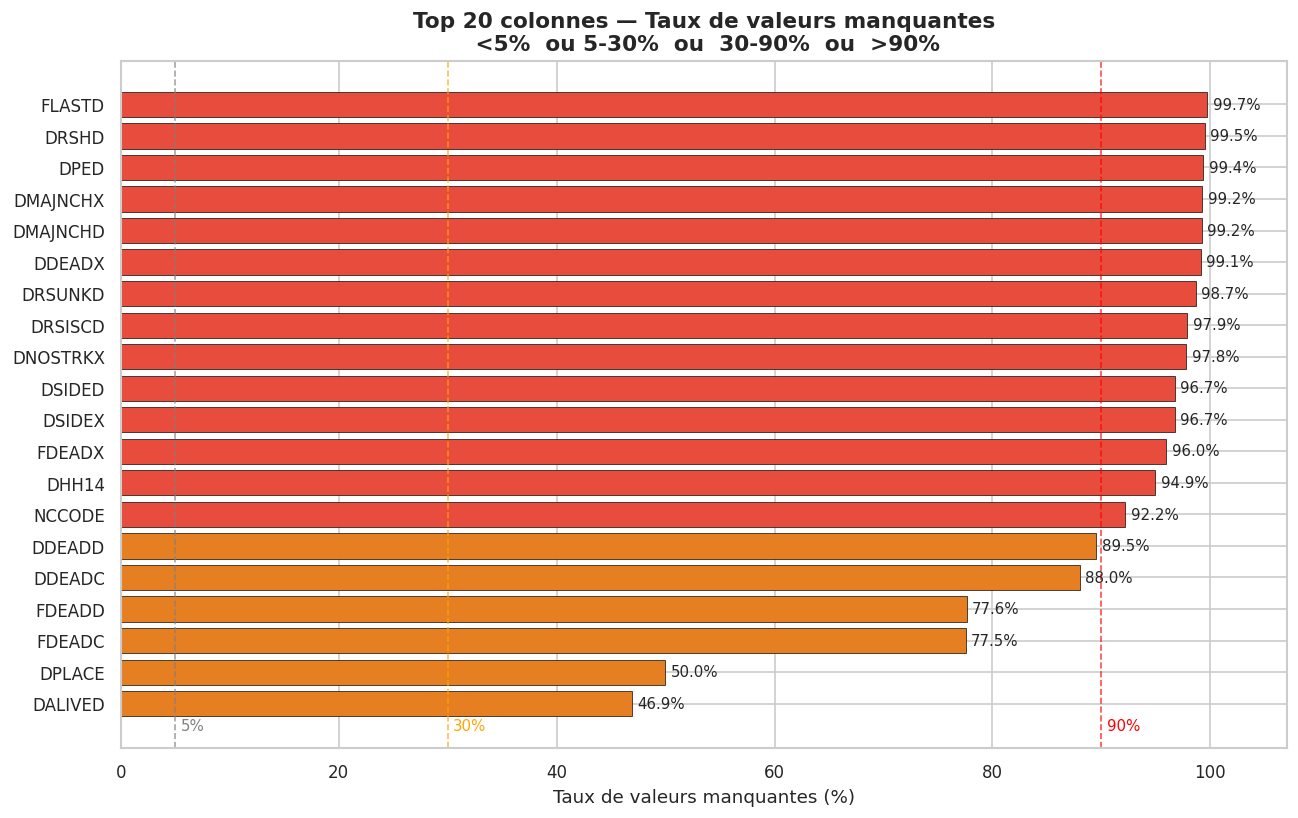

 Graphique sauvegardé


In [8]:
# ============================================================
# 4.2 — Visualisation des NaN (Top 20) — VERSION CORRIGÉE
# ============================================================

top_missing = (
    missing_table[missing_table["missing_pct (%)"] > 0]
    .head(20)
    .sort_values("missing_pct (%)", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

# Couleurs par seuil
colors = [
    "#e74c3c" if v > 90
    else "#e67e22" if v > 30
    else "#f39c12" if v > 5
    else "#2ecc71"
    for v in top_missing["missing_pct (%)"]
]

bars = ax.barh(
    top_missing.index,
    top_missing["missing_pct (%)"],
    color=colors,
    edgecolor="black",
    linewidth=0.4
)

# Annotations des valeurs (à droite de chaque barre)
for bar, val in zip(bars, top_missing["missing_pct (%)"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9
    )

# ─── CORRECTION : utiliser ax.get_xaxis_transform() ──────────────────
# get_xaxis_transform() permet de mixer :
#   - x en coordonnées DATA (valeur sur l'axe X = %)
#   - y en coordonnées AXES normalisées (0 = bas, 1 = haut du graphique)
# Sans ça, y=0.5 est interprété comme une donnée catégorielle → erreur/décalage

for thresh, lbl, col in [
    (5,  "5%",  "gray"),
    (30, "30%", "orange"),
    (90, "90%", "red")
]:
    ax.axvline(
        x=thresh, color=col,
        linestyle="--", linewidth=1, alpha=0.7
    )
    ax.text(
        thresh + 0.5,   # x en coordonnées DATA (%)
        0.02,           # y en coordonnées AXES normalisées (0=bas, 1=haut)
        lbl,
        color=col,
        fontsize=9,
        va="bottom",
        transform=ax.get_xaxis_transform()   # ← LE FIX
    )

ax.set_xlabel("Taux de valeurs manquantes (%)", fontsize=11)
ax.set_title(
    "Top 20 colonnes — Taux de valeurs manquantes\n"
    " <5%  ou 5-30%  ou  30-90%  ou  >90%",
    fontsize=13, fontweight="bold"
)
ax.set_xlim(0, 107)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Graphique sauvegardé")

In [9]:
# ============================================================
# 4.3 — Focus sur les features baseline uniquement
# ============================================================

# Variables baseline candidates pour l'Axe 2
BASELINE_FEATURES = [
    "RDELAY", "RCONSC", "SEX", "AGE", "RSLEEP", "RATRIAL",
    "RCT", "RVISINF", "RHEP24", "RASP3", "RSBP",
    "RDEF1", "RDEF2", "RDEF3", "RDEF4", "RDEF5",
    "RDEF6", "RDEF7", "RDEF8", "STYPE"
]
baseline_present = [c for c in BASELINE_FEATURES if c in df.columns]

baseline_missing = missing_table.loc[
    missing_table.index.intersection(baseline_present)
].sort_values("missing_pct (%)", ascending=False)

print("Valeurs manquantes dans les features BASELINE uniquement :")
print("(Ces variables seront utilisées pour l'Axe 2)")
print()
if baseline_missing[baseline_missing["missing_count"] > 0].empty:
    print("Aucun NaN dans les features baseline")
else:
    display(baseline_missing[baseline_missing["missing_count"] > 0])

print()
print("Conclusion :")
print("  RATRIAL et RASP3 : ~5% NaN → phase pilote (984 patients) → imputation par mode")
print("  RHEP24           : ~2% NaN → donnée non collectée → imputation par mode")
print("  Autres baseline  : complètes → aucun traitement nécessaire")


Valeurs manquantes dans les features BASELINE uniquement :
(Ces variables seront utilisées pour l'Axe 2)



,missing_count,missing_pct (%),type,categorie
RATRIAL,984,5.060,object,5-30%
RASP3,984,5.060,object,5-30%
RHEP24,344,1.770,object,<5%



Conclusion :
  RATRIAL et RASP3 : ~5% NaN → phase pilote (984 patients) → imputation par mode
  RHEP24           : ~2% NaN → donnée non collectée → imputation par mode
  Autres baseline  : complètes → aucun traitement nécessaire


---
## Section 5 — Qualité des données

### 5.1 Ce qu'on vérifie

Au-delà des NaN, la qualité des données cliniques implique de vérifier :
- les **doublons** : mêmes patients enregistrés deux fois
- les **valeurs codées impossibles** : RSBP = 0 (tension à zéro = erreur de saisie)
- les **codes spéciaux** : `U`, `C`, `99` qui signifient "inconnu" ou "non évaluable"
- les **modalités inattendues** : valeurs hors de la documentation IST


In [10]:
# ============================================================
# 5.1 — Vérification des doublons
# ============================================================

n_dup = df.duplicated().sum()
n_dup_key = df.duplicated(subset=["HOSPNUM"]).sum()

print("Vérification des doublons :")
print(f"  Doublons exacts (toutes colonnes) : {n_dup}")
print(f"  HOSPNUM dupliqués                 : {n_dup_key}")
print()
if n_dup == 0:
    print("Aucun doublon exact détecté — dataset intègre")
else:
    print("Des doublons existent — investigation nécessaire")


Vérification des doublons :
  Doublons exacts (toutes colonnes) : 0
  HOSPNUM dupliqués                 : 18969

Aucun doublon exact détecté — dataset intègre


Analyse de RSBP (pression artérielle systolique) :
  RSBP = 0          : 0 patients  ← ERREUR DE SAISIE (0 mmHg impossible)
  RSBP > 300        : 0 patients  ← valeur extrême suspecte
  0 < RSBP < 70     : 0 patients  ← cliniquement très rare
  Médiane RSBP       : 160.0 mmHg
  Plage normale AVC  : 90–280 mmHg

RSBP = 0 doit être remplacé par NaN avant imputation (correction prévue en V2)


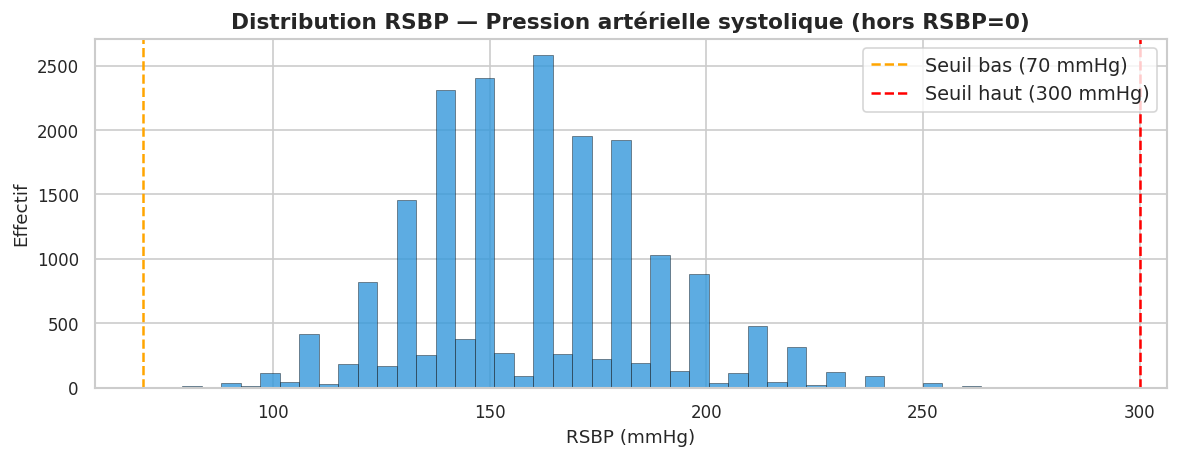

In [11]:
# ============================================================
# 5.2 — Détection des valeurs aberrantes cliniques (RSBP = 0)
# ============================================================

# RSBP (Systolic Blood Pressure) : une valeur de 0 mmHg est cliniquement impossible
# C'est un code de saisie manquante déguisé en 0

rsbp_zero    = (df["RSBP"] == 0).sum()
rsbp_extreme = (df["RSBP"] > 300).sum()
rsbp_low     = ((df["RSBP"] > 0) & (df["RSBP"] < 70)).sum()

print("Analyse de RSBP (pression artérielle systolique) :")
print(f"  RSBP = 0          : {rsbp_zero} patients  ← ERREUR DE SAISIE (0 mmHg impossible)")
print(f"  RSBP > 300        : {rsbp_extreme} patients  ← valeur extrême suspecte")
print(f"  0 < RSBP < 70     : {rsbp_low} patients  ← cliniquement très rare")
print(f"  Médiane RSBP       : {df['RSBP'].median()} mmHg")
print(f"  Plage normale AVC  : 90–280 mmHg")
print()
print("RSBP = 0 doit être remplacé par NaN avant imputation (correction prévue en V2)")

# Visualisation de la distribution RSBP avec marquage des anomalies
fig, ax = plt.subplots(figsize=(10, 4))
df_plot = df[df["RSBP"] > 0]["RSBP"]  # exclure les 0 pour la distrib
ax.hist(df_plot, bins=50, color="#3498db", edgecolor="black", linewidth=0.3, alpha=0.8)
ax.axvline(x=70,  color="orange", linestyle="--", linewidth=1.5, label="Seuil bas (70 mmHg)")
ax.axvline(x=300, color="red",    linestyle="--", linewidth=1.5, label="Seuil haut (300 mmHg)")
ax.set_title("Distribution RSBP — Pression artérielle systolique (hors RSBP=0)", fontweight="bold")
ax.set_xlabel("RSBP (mmHg)")
ax.set_ylabel("Effectif")
ax.legend()
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_rsbp_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# ============================================================
# 5.3 — Codes spéciaux dans les variables catégorielles
# ============================================================

# Les variables RDEF ont 3 modalités possibles : Y, N, C
# C = "can't assess" (non évaluable) — c'est de l'INFORMATION, pas un NaN

print("Modalités présentes dans les variables RDEF :")
print()
rdef_cols = [f"RDEF{i}" for i in range(1, 9)]

summary_rdef = {}
for col in rdef_cols:
    counts = df[col].value_counts(dropna=False)
    pct_c  = (df[col] == "C").sum() / len(df) * 100
    pct_nan = df[col].isna().mean() * 100
    summary_rdef[col] = {
        "Y": int(counts.get("Y", 0)),
        "N": int(counts.get("N", 0)),
        "C (can't assess)": int(counts.get("C", 0)),
        "NaN": int(df[col].isna().sum()),
        "% C": round(pct_c, 2),
        "% NaN": round(pct_nan, 2)
    }

summary_df = pd.DataFrame(summary_rdef).T
display(summary_df)

print()
print("Codes spéciaux identifiés dans d'autres variables :")
for col in ["RATRIAL", "RSLEEP", "RCT", "RVISINF", "RHEP24", "RASP3"]:
    if col in df.columns:
        modalities = df[col].value_counts(dropna=False).to_dict()
        print(f"  {col:10s} : {modalities}")


Modalités présentes dans les variables RDEF :



,Y,N,C (can't assess),NaN,% C,% NaN
RDEF1,14099.000,5089.000,247.000,0.000,1.270,0.000
RDEF2,16645.000,2667.000,123.000,0.000,0.630,0.000
RDEF3,14678.000,4502.000,255.000,0.000,1.310,0.000
RDEF4,8509.000,10342.000,584.000,0.000,3.000,0.000
RDEF5,3096.000,12394.000,3945.000,0.000,20.300,0.000
RDEF6,3178.000,12809.000,3448.000,0.000,17.740,0.000
RDEF7,2139.000,15704.000,1592.000,0.000,8.190,0.000
RDEF8,1219.000,16967.000,1249.000,0.000,6.430,0.000



Codes spéciaux identifiés dans d'autres variables :
  RATRIAL    : {'N': 15282, 'Y': 3169, nan: 984}
  RSLEEP     : {'N': 13750, 'Y': 5685}
  RCT        : {'Y': 13024, 'N': 6411}
  RVISINF    : {'N': 13020, 'Y': 6415}
  RHEP24     : {'N': 18655, 'Y': 436, nan: 344}
  RASP3      : {'N': 14511, 'Y': 3940, nan: 984}


---
## Section 6 — Analyse des variables numériques

### 6.1 Variables numériques cliniquement importantes pour l'Axe 2

Parmi les 49 variables numériques, 3 sont directement pertinentes pour l'Axe 2 :

| Variable | Description | Plage attendue |
|----------|-------------|----------------|
| `AGE` | Âge en années | 16–99 ans |
| `RDELAY` | Délai admission → randomisation (heures) | 1–48h (critère d'inclusion IST) |
| `RSBP` | Pression artérielle systolique (mmHg) | 90–280 mmHg |

Les variables dérivées (`EXPDD`, `EXPD6`, `EXPD14`, `DIED`, `TD`) sont à exclure  
car elles contiennent de l'information de pronostic future (leakage potentiel).


In [13]:
# ============================================================
# 6.1 — Statistiques descriptives des variables numériques cliniques
# ============================================================

clinical_num = ["AGE", "RDELAY", "RSBP"]
clinical_num_present = [c for c in clinical_num if c in df.columns]

print("Statistiques descriptives — Variables numériques cliniques :")
display(df[clinical_num_present].describe().T.round(2))

print()
print("Points d'attention :")
print(f"  AGE    : min={df['AGE'].min()}, max={df['AGE'].max()}, médiane={df['AGE'].median()}")
print(f"           → 26.4% des patients ont plus de 80 ans (population âgée)")
print(f"  RDELAY : min={df['RDELAY'].min()}, max={df['RDELAY'].max()}, médiane={df['RDELAY'].median()}")
print(f"           → Délai max 48h (critère d'inclusion IST)")
print(f"  RSBP   : min={df['RSBP'].min()}, max={df['RSBP'].max()}, médiane={df['RSBP'].median()}")
print(f"           → RSBP=0 : {(df['RSBP']==0).sum()} cas → erreur de saisie")


Statistiques descriptives — Variables numériques cliniques :


,count,mean,std,min,25%,50%,75%,max
AGE,19435.000,71.720,11.620,16.000,65.000,73.000,80.000,99.000
RDELAY,19435.000,20.120,12.470,1.000,9.000,19.000,29.000,48.000
RSBP,19435.000,160.160,27.610,70.000,140.000,160.000,180.000,295.000



Points d'attention :
  AGE    : min=16, max=99, médiane=73.0
           → 26.4% des patients ont plus de 80 ans (population âgée)
  RDELAY : min=1, max=48, médiane=19.0
           → Délai max 48h (critère d'inclusion IST)
  RSBP   : min=70, max=295, médiane=160.0
           → RSBP=0 : 0 cas → erreur de saisie


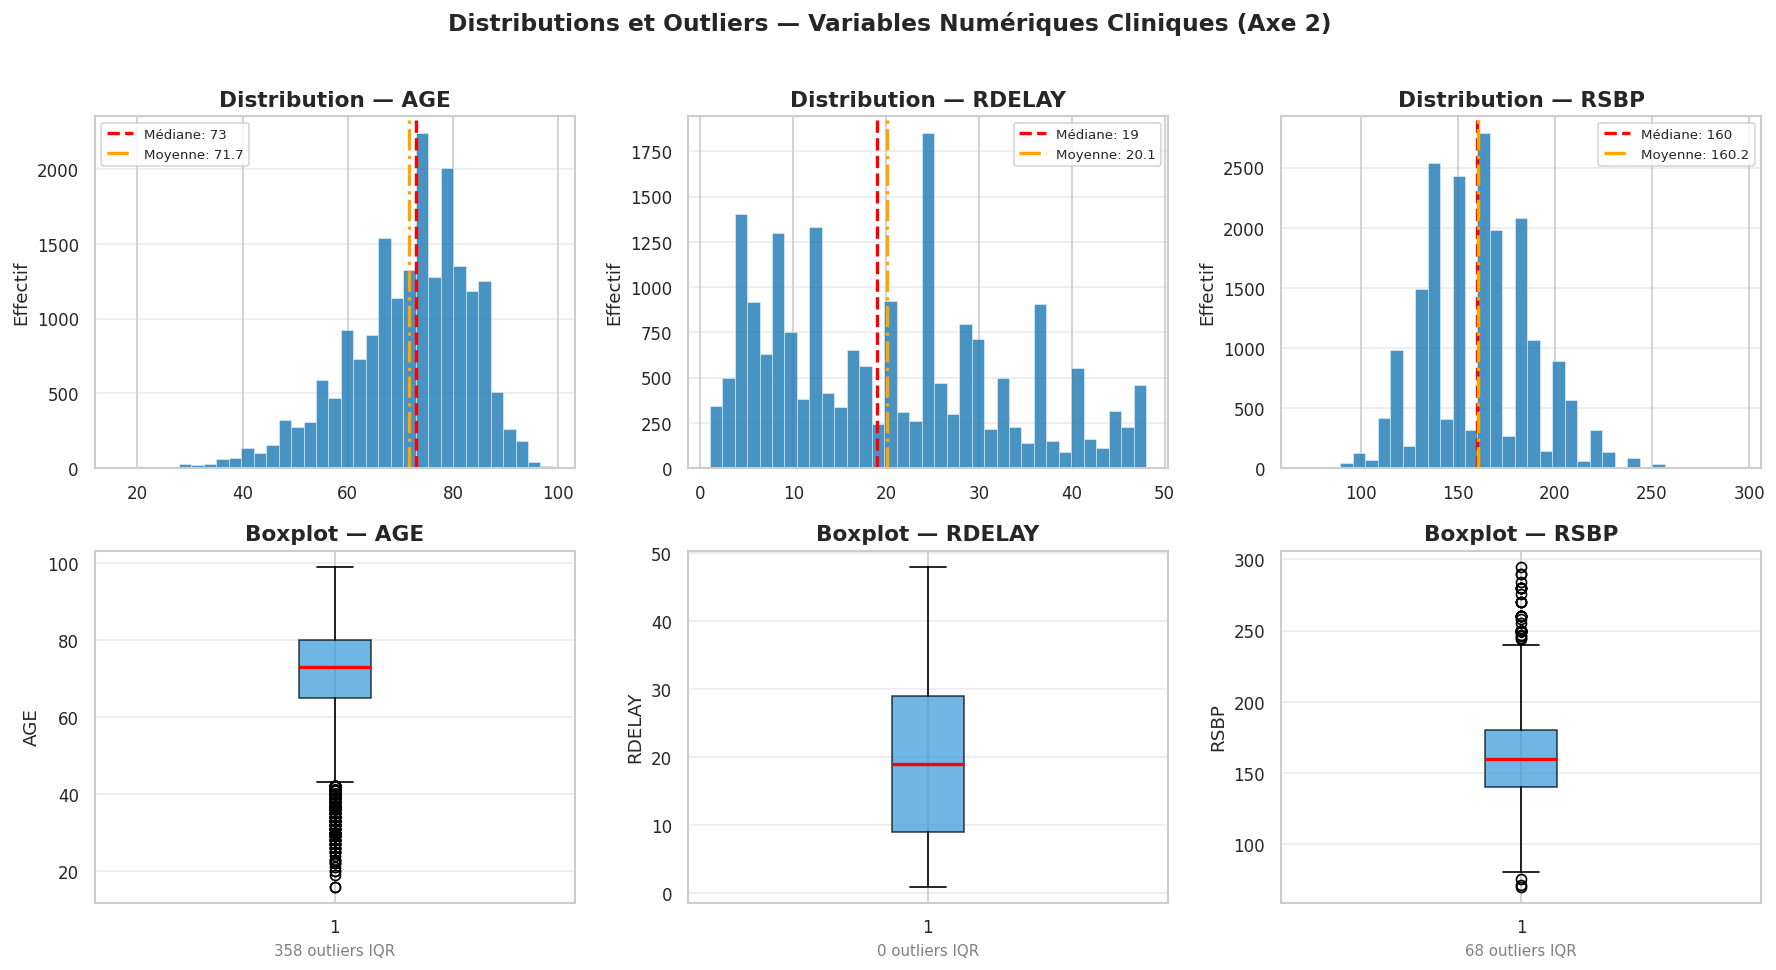

In [14]:
# ============================================================
# 6.2 — Distributions et outliers — AGE, RDELAY, RSBP
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, (ax_hist, ax_box) in zip(
    clinical_num_present,
    [(axes[0,0], axes[1,0]), (axes[0,1], axes[1,1]), (axes[0,2], axes[1,2])]
):
    data = df[col].dropna()
    data_clean = data[data > 0] if col == "RSBP" else data

    # Histogramme
    ax_hist.hist(data_clean, bins=35, color="#2980b9", edgecolor="white",
                 linewidth=0.3, alpha=0.85)
    ax_hist.axvline(data_clean.median(), color="red", linewidth=2,
                    linestyle="--", label=f"Médiane: {data_clean.median():.0f}")
    ax_hist.axvline(data_clean.mean(), color="orange", linewidth=2,
                    linestyle="-.", label=f"Moyenne: {data_clean.mean():.1f}")
    ax_hist.set_title(f"Distribution — {col}", fontweight="bold")
    ax_hist.set_ylabel("Effectif")
    ax_hist.legend(fontsize=8)
    ax_hist.grid(axis="y", alpha=0.4)

    # Boxplot
    ax_box.boxplot(data_clean, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="#3498db", alpha=0.7),
                   medianprops=dict(color="red", linewidth=2))
    ax_box.set_title(f"Boxplot — {col}", fontweight="bold")
    ax_box.set_ylabel(col)
    ax_box.grid(axis="y", alpha=0.4)

    # Commentaire outliers
    Q1, Q3 = data_clean.quantile(0.25), data_clean.quantile(0.75)
    IQR = Q3 - Q1
    n_outliers = ((data_clean < Q1 - 1.5*IQR) | (data_clean > Q3 + 1.5*IQR)).sum()
    ax_box.set_xlabel(f"{n_outliers} outliers IQR", fontsize=9, color="gray")

plt.suptitle("Distributions et Outliers — Variables Numériques Cliniques (Axe 2)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Interprétation clinique des distributions

**AGE :**  
Distribution légèrement asymétrique à gauche, centrée autour de 73 ans.  
26.4% des patients ont plus de 80 ans — c'est une population âgée, représentative de l'AVC réel.  
Les valeurs extrêmes (âge 16–99) sont **cliniquement plausibles**, pas des erreurs.

**RDELAY :**  
Délai entre le début des symptômes et la randomisation.  
Le maximum de 48h est le critère d'inclusion de l'essai IST.  
La médiane (~19h) indique que la plupart des patients arrivent tardivement — contexte de l'époque (1991–1996).

**RSBP :**  
Pression artérielle systolique à l'admission.  
La médiane de 160 mmHg est typique d'une urgence AVC (hypertension réactionnelle).  
Les valeurs à 0 mmHg (~quelques cas) sont des **erreurs de saisie** → à convertir en NaN.


---
## Section 7 — Analyse des variables catégorielles

### 7.1 Variables catégorielles clés pour l'Axe 2

| Variable | Description | Modalités |
|----------|-------------|-----------|
| `SEX` | Sexe du patient | M / F |
| `RCONSC` | État de conscience à l'admission | F / D / U |
| `STYPE` | Type d'AVC (Oxfordshire Community Stroke Project) | TACS / PACS / POCS / LACS / OTH |
| `RATRIAL` | Fibrillation auriculaire | Y / N |
| `RCT` | CT-scan fait avant randomisation | Y / N |
| `RSLEEP` | Symptômes apparus pendant le sommeil | Y / N |


In [15]:
# ============================================================
# 7.1 — Fréquences des variables catégorielles clés
# ============================================================

key_cat = ["SEX", "RCONSC", "STYPE", "RATRIAL", "RCT", "RSLEEP"]
key_cat_present = [c for c in key_cat if c in df.columns]

print("Distribution des variables catégorielles clés :")
print("=" * 60)

for col in key_cat_present:
    counts  = df[col].value_counts(dropna=False)
    pct     = df[col].value_counts(dropna=False, normalize=True) * 100
    summary = pd.DataFrame({"count": counts, "pct (%)": pct.round(2)})
    print(f"\n▶ {col}")
    display(summary)


Distribution des variables catégorielles clés :

▶ SEX


,count,pct (%)
SEX,,
M,10407,53.550
F,9028,46.450



▶ RCONSC


,count,pct (%)
RCONSC,,
F,14921,76.770
D,4254,21.890
U,260,1.340



▶ STYPE


...

,count,pct (%)
RATRIAL,,
N,15282,78.630
Y,3169,16.310
NaN,984,5.060



▶ RCT


,count,pct (%)
RCT,,
Y,13024,67.010
N,6411,32.990



▶ RSLEEP


,count,pct (%)
RSLEEP,,
N,13750,70.750
Y,5685,29.250


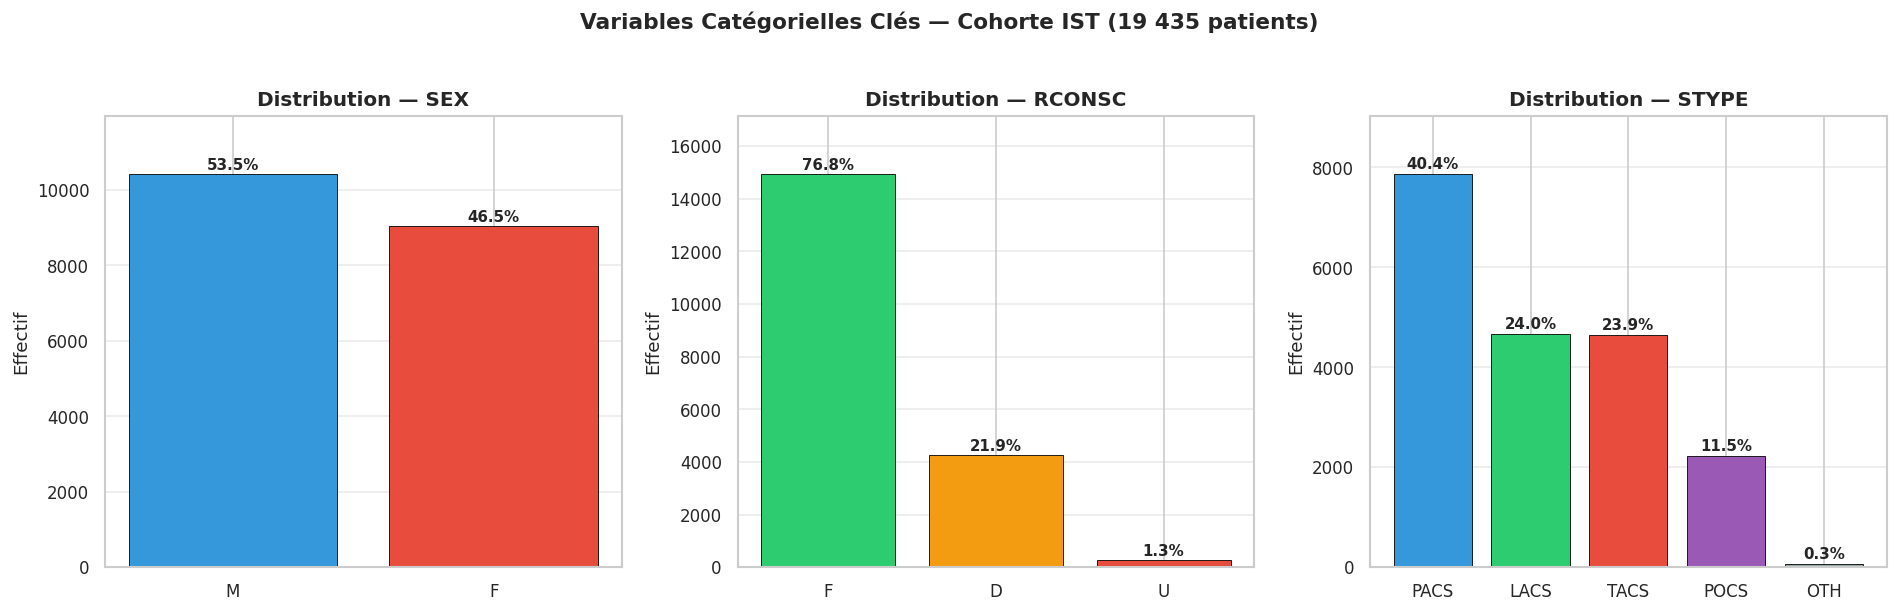

In [16]:
# ============================================================
# 7.2 — Visualisation des 3 variables catégorielles majeures
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Palette clinique
palettes = {
    "SEX"    : {"M": "#3498db", "F": "#e74c3c"},
    "RCONSC" : {"F": "#2ecc71", "D": "#f39c12", "U": "#e74c3c"},
    "STYPE"  : {"PACS": "#3498db", "LACS": "#2ecc71", "TACS": "#e74c3c",
                 "POCS": "#9b59b6", "OTH": "#95a5a6"}
}

for ax, col in zip(axes, ["SEX", "RCONSC", "STYPE"]):
    order  = df[col].value_counts().index.tolist()
    counts = df[col].value_counts()
    total  = counts.sum()
    colors = [palettes[col].get(k, "#95a5a6") for k in order]

    bars = ax.bar(range(len(order)), [counts[k] for k in order],
                  color=colors, edgecolor="black", linewidth=0.5)

    for bar, key in zip(bars, order):
        pct = counts[key] / total * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, fontsize=10)
    ax.set_title(f"Distribution — {col}", fontweight="bold", fontsize=12)
    ax.set_ylabel("Effectif")
    ax.set_ylim(0, counts.max() * 1.15)
    ax.grid(axis="y", alpha=0.4)

plt.suptitle("Variables Catégorielles Clés — Cohorte IST (19 435 patients)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Interprétation clinique des distributions catégorielles

**SEX :** 53.5% hommes / 46.5% femmes — répartition équilibrée, représentative de la population AVC.

**RCONSC :**
- `F` (Fully conscious) : **76.8%** — majorité consciente à l'admission
- `D` (Drowsy) : **21.9%** — somnolents
- `U` (Unconscious) : **1.3%** — très peu d'inconscients → classe rare dans la cible `sévère`

**STYPE — Type d'AVC :**
- `PACS` (Partial Anterior) : **40.4%** — le plus fréquent
- `LACS` (Lacunar) : **24.0%** — AVC lacunaire, typiquement léger
- `TACS` (Total Anterior) : **23.9%** — AVC total, typiquement sévère
- `POCS` (Posterior) : **11.5%**
- `OTH` (Autre) : **0.3%** → trop rare, à regrouper ou exclure

> **Point clé :** STYPE est le prédicteur le plus important attendu pour la sévérité.  
> TACS → sévère · LACS → léger · PACS/POCS → intermédiaire


---
## Section 8 — Analyse approfondie des variables RDEF

### 8.1 Pourquoi une section dédiée aux RDEF ?

Les variables `RDEF1..RDEF8` sont **cruciales** pour l'Axe 2 :  
elles entrent directement dans la formule de construction de `severity_class`.

Chacune représente un type de déficit neurologique évalué à l'admission :

| Variable | Déficit évalué |
|----------|----------------|
| RDEF1 | Déficit facial (paralysie faciale) |
| RDEF2 | Déficit bras/main |
| RDEF3 | Déficit jambe/pied |
| RDEF4 | Aphasie (troubles du langage) |
| RDEF5 | Hémianopsie (perte du champ visuel) |
| RDEF6 | Trouble visuospatial |
| RDEF7 | Signes cérébelleux / tronc cérébral |
| RDEF8 | Autre déficit |

**Les 3 modalités :**
- `Y` = déficit présent → 1
- `N` = déficit absent → 0
- `C` = "can't assess" (non évaluable) → ** Information clinique, pas un NaN !**

### 8.2 Le problème du "C"

`C` signifie que l'évaluateur **ne pouvait pas tester** ce déficit  
(patient inconscient, non coopératif, etc.).  
Un patient qui ne peut pas être évalué sur un déficit est probablement **plus grave**,  
pas "neutre". Traiter `C` comme NaN et l'imputer par 0 est **cliniquement incorrect**.

En V1 : `C → NaN → imputation médiane` (simplifié)  
En V2 prévu : `C → 0.5 + indicateur _uncertain` (cliniquement justifié)


In [17]:
# ============================================================
# 8.1 — Distribution détaillée des modalités RDEF
# ============================================================

rdef_cols = [f"RDEF{i}" for i in range(1, 9)]

# Construction du tableau récapitulatif
rdef_summary = []
for col in rdef_cols:
    total = len(df)
    n_Y   = (df[col] == "Y").sum()
    n_N   = (df[col] == "N").sum()
    n_C   = (df[col] == "C").sum()
    n_nan = df[col].isna().sum()
    rdef_summary.append({
        "Variable" : col,
        "Y (présent)": n_Y,
        "N (absent)" : n_N,
        "C (can't assess)": n_C,
        "NaN"       : n_nan,
        "% Y"       : round(n_Y/total*100, 1),
        "% N"       : round(n_N/total*100, 1),
        "% C"       : round(n_C/total*100, 1),
        "% NaN"     : round(n_nan/total*100, 2),
    })

rdef_df = pd.DataFrame(rdef_summary).set_index("Variable")
print("Distribution détaillée des variables RDEF :")
display(rdef_df)

print()
total_C   = sum((df[col] == "C").sum() for col in rdef_cols)
total_cells = len(rdef_cols) * len(df)
print(f"Total de 'C' dans l'ensemble des RDEF : {total_C:,} / {total_cells:,} "
      f"({total_C/total_cells*100:.2f}%)")


Distribution détaillée des variables RDEF :


,Y (présent),N (absent),C (can't assess),NaN,% Y,% N,% C,% NaN
Variable,,,,,,,,
RDEF1,14099,5089,247,0,72.500,26.200,1.300,0.000
RDEF2,16645,2667,123,0,85.600,13.700,0.600,0.000
RDEF3,14678,4502,255,0,75.500,23.200,1.300,0.000
RDEF4,8509,10342,584,0,43.800,53.200,3.000,0.000
RDEF5,3096,12394,3945,0,15.900,63.800,20.300,0.000
RDEF6,3178,12809,3448,0,16.400,65.900,17.700,0.000
RDEF7,2139,15704,1592,0,11.000,80.800,8.200,0.000
RDEF8,1219,16967,1249,0,6.300,87.300,6.400,0.000



Total de 'C' dans l'ensemble des RDEF : 11,443 / 155,480 (7.36%)


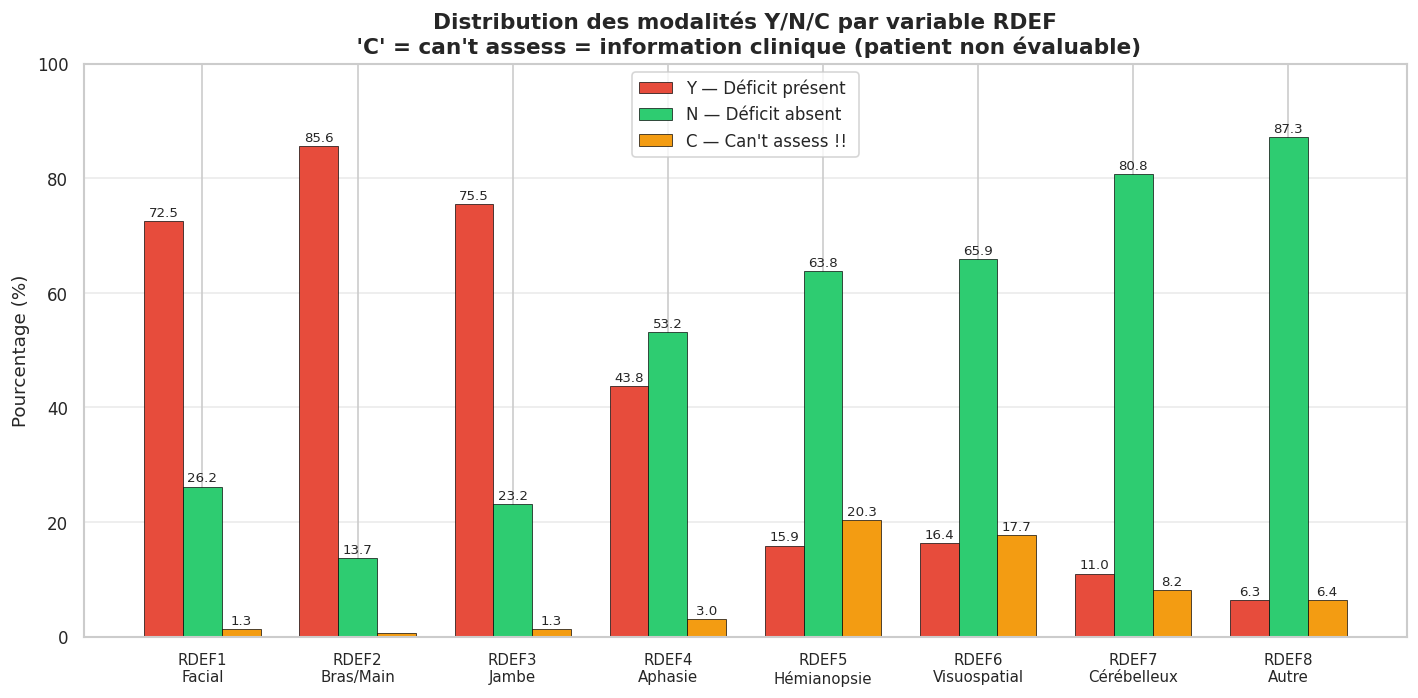

In [18]:
# ============================================================
# 8.2 — Visualisation des modalités RDEF (stacked bar)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(rdef_cols))
w = 0.25

pct_Y = [rdef_df.loc[col, "% Y"] for col in rdef_cols]
pct_N = [rdef_df.loc[col, "% N"] for col in rdef_cols]
pct_C = [rdef_df.loc[col, "% C"] for col in rdef_cols]

bars_Y = ax.bar(x - w, pct_Y, w, label="Y — Déficit présent",       color="#e74c3c", edgecolor="black", lw=0.4)
bars_N = ax.bar(x,     pct_N, w, label="N — Déficit absent",         color="#2ecc71", edgecolor="black", lw=0.4)
bars_C = ax.bar(x + w, pct_C, w, label="C — Can't assess !! ",        color="#f39c12", edgecolor="black", lw=0.4)

# Annotations
for bar_group in [bars_Y, bars_N, bars_C]:
    for bar in bar_group:
        h = bar.get_height()
        if h > 1:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                    f"{h:.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f"{col}\n{desc}" for col, desc in zip(rdef_cols,
    ["Facial", "Bras/Main", "Jambe", "Aphasie", "Hémianopsie", "Visuospatial", "Cérébelleux", "Autre"])],
    fontsize=9)
ax.set_ylabel("Pourcentage (%)", fontsize=11)
ax.set_title("Distribution des modalités Y/N/C par variable RDEF\n"
             " 'C' = can't assess = information clinique (patient non évaluable)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_rdef_modalites.png", dpi=150, bbox_inches="tight")
plt.show()


In [19]:
# ============================================================
# 8.3 — Analyse du "C" par type d'AVC (STYPE) → validation clinique
# ============================================================

# Hypothèse : les patients TACS (AVC total) devraient avoir plus de "C"
# car ils sont souvent inconscients ou non coopératifs

print("Taux de 'C' dans RDEF1..8 par type d'AVC (STYPE) :")
print("(Validation clinique : TACS devrait avoir le taux le plus élevé)")
print()

stype_c_rates = {}
for stype in ["TACS", "PACS", "LACS", "POCS"]:
    mask = df["STYPE"] == stype
    n_patients = mask.sum()
    if n_patients == 0:
        continue
    n_C_total = sum((df.loc[mask, col] == "C").sum() for col in rdef_cols)
    total_evals = n_patients * len(rdef_cols)
    pct_C = n_C_total / total_evals * 100
    stype_c_rates[stype] = {
        "n_patients": n_patients,
        "n_C_total" : n_C_total,
        "% C global": round(pct_C, 2)
    }

stype_c_df = pd.DataFrame(stype_c_rates).T
display(stype_c_df)

print()
print("Interprétation attendue :")
print("  TACS → taux C le plus élevé (patients inconscients, difficiles à évaluer)")
print("  LACS → taux C le plus faible (patients conscients, AVC lacunaires)")


Taux de 'C' dans RDEF1..8 par type d'AVC (STYPE) :
(Validation clinique : TACS devrait avoir le taux le plus élevé)



,n_patients,n_C_total,% C global
TACS,4638.000,6139.000,16.550
PACS,7855.000,4374.000,6.960
LACS,4657.000,22.000,0.060
POCS,2228.000,908.000,5.090



Interprétation attendue :
  TACS → taux C le plus élevé (patients inconscients, difficiles à évaluer)
  LACS → taux C le plus faible (patients conscients, AVC lacunaires)


Distribution du RDEF_score (C traité comme NaN — méthode V1) :


,count
RDEF_score_v1,
0.000,52
1.000,1825
2.000,3282
3.000,5769
4.000,5351
5.000,2452
6.000,614
7.000,65
8.000,8


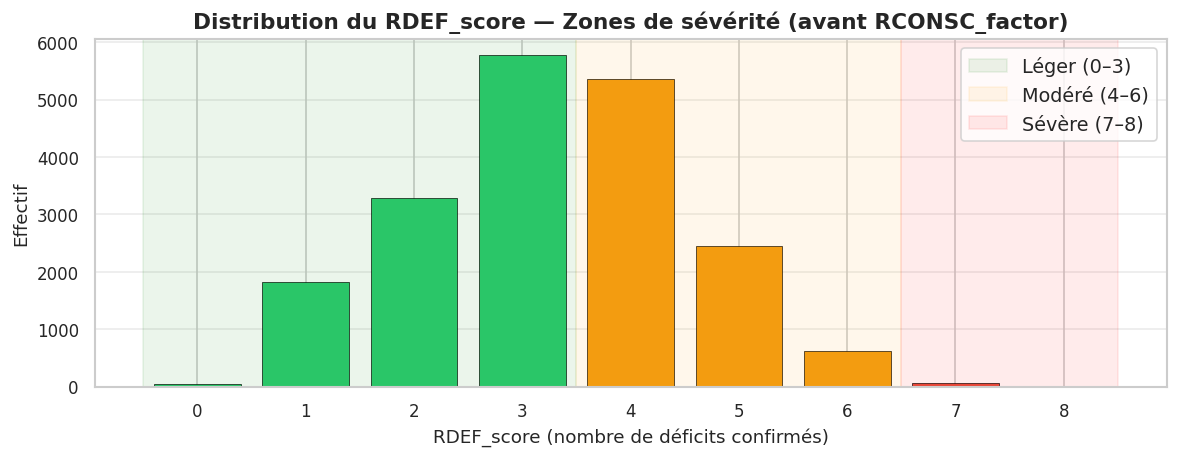

In [20]:
# ============================================================
# 8.4 — RDEF_score exploratoire et impact des "C"
# ============================================================

# Calcul du RDEF_score en traitant C comme NaN (méthode V1 — simplifiée)
for col in rdef_cols:
    df[col + "_bin_v1"] = df[col].map({"Y": 1, "N": 0, "C": np.nan})

df["RDEF_score_v1"] = df[[col+"_bin_v1" for col in rdef_cols]].sum(axis=1, min_count=1)

# Distribution du RDEF_score
print("Distribution du RDEF_score (C traité comme NaN — méthode V1) :")
rdef_score_dist = df["RDEF_score_v1"].value_counts().sort_index()
display(rdef_score_dist.to_frame("count"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(rdef_score_dist.index, rdef_score_dist.values,
       color=["#2ecc71" if v <= 3 else "#f39c12" if v <= 6 else "#e74c3c" for v in rdef_score_dist.index],
       edgecolor="black", linewidth=0.4)

# Zones de sévérité
ax.axvspan(-0.5, 3.5, alpha=0.08, color="green",  label="Léger (0–3)")
ax.axvspan(3.5,  6.5, alpha=0.08, color="orange", label="Modéré (4–6)")
ax.axvspan(6.5,  8.5, alpha=0.08, color="red",    label="Sévère (7–8)")
ax.set_xticks(range(0, 9))
ax.set_xlabel("RDEF_score (nombre de déficits confirmés)", fontsize=11)
ax.set_ylabel("Effectif", fontsize=11)
ax.set_title("Distribution du RDEF_score — Zones de sévérité (avant RCONSC_factor)",
             fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_rdef_score.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 9 — Construction exploratoire de la cible `severity_class`

### 9.1 Pourquoi construire la cible dès l'EDA ?

La variable `severity_class` n'existe pas dans l'IST.  
L'explorer en EDA permet de :
- vérifier que la formule du cahier des charges est **applicable** sur ce dataset,
- voir si les 3 classes sont **suffisamment représentées** pour la modélisation,
- identifier les cas où la cible est **non calculable** (trop de NaN),
- détecter des **signaux cliniques** dans les distributions.

### 9.2 Rappel de la formule

```
RDEF_score    = Σ RDEF_i_bin  (Y=1, N=0, C→NaN en V1)
RCONSC_factor = F→0, D→1, U→2
severity_score = RDEF_score + 2 × RCONSC_factor

Seuils : 0–3 → léger | 4–6 → modéré | 7+ → sévère
```


In [21]:
# ============================================================
# 9.1 — Construction complète de severity_class (exploratoire)
# ============================================================

# Encodage RCONSC
df["RCONSC_factor"] = df["RCONSC"].map({"F": 0, "D": 1, "U": 2})

# Score de sévérité composite
df["severity_score"] = df["RDEF_score_v1"] + 2 * df["RCONSC_factor"]

# Classification en 3 classes
df["severity_class"] = pd.cut(
    df["severity_score"],
    bins=[-np.inf, 3, 6, np.inf],
    labels=["leger", "modere", "severe"]
)

# Distribution
dist       = df["severity_class"].value_counts()
dist_pct   = df["severity_class"].value_counts(normalize=True) * 100
n_calculable = df["severity_class"].notna().sum()
n_manquants  = df["severity_class"].isna().sum()

print("=" * 55)
print("DISTRIBUTION DE LA CIBLE severity_class")
print("=" * 55)
summary_target = pd.DataFrame({
    "count": dist,
    "pct (%)": dist_pct.round(2),
    "pct sur calculable (%)": (dist / n_calculable * 100).round(2)
})
display(summary_target)

print()
print(f"Patients avec cible calculable : {n_calculable:,} ({n_calculable/len(df)*100:.1f}%)")
print(f"Patients sans cible (NaN)      : {n_manquants:,} ({n_manquants/len(df)*100:.1f}%)")
print()
print(" Déséquilibre : sévère ≈ 8% → nécessite class_weight='balanced' ou SMOTE")


DISTRIBUTION DE LA CIBLE severity_class


,count,pct (%),pct sur calculable (%)
severity_class,,,
leger,9692,49.910,49.910
modere,8096,41.690,41.690
severe,1630,8.390,8.390



Patients avec cible calculable : 19,418 (99.9%)
Patients sans cible (NaN)      : 17 (0.1%)

 Déséquilibre : sévère ≈ 8% → nécessite class_weight='balanced' ou SMOTE


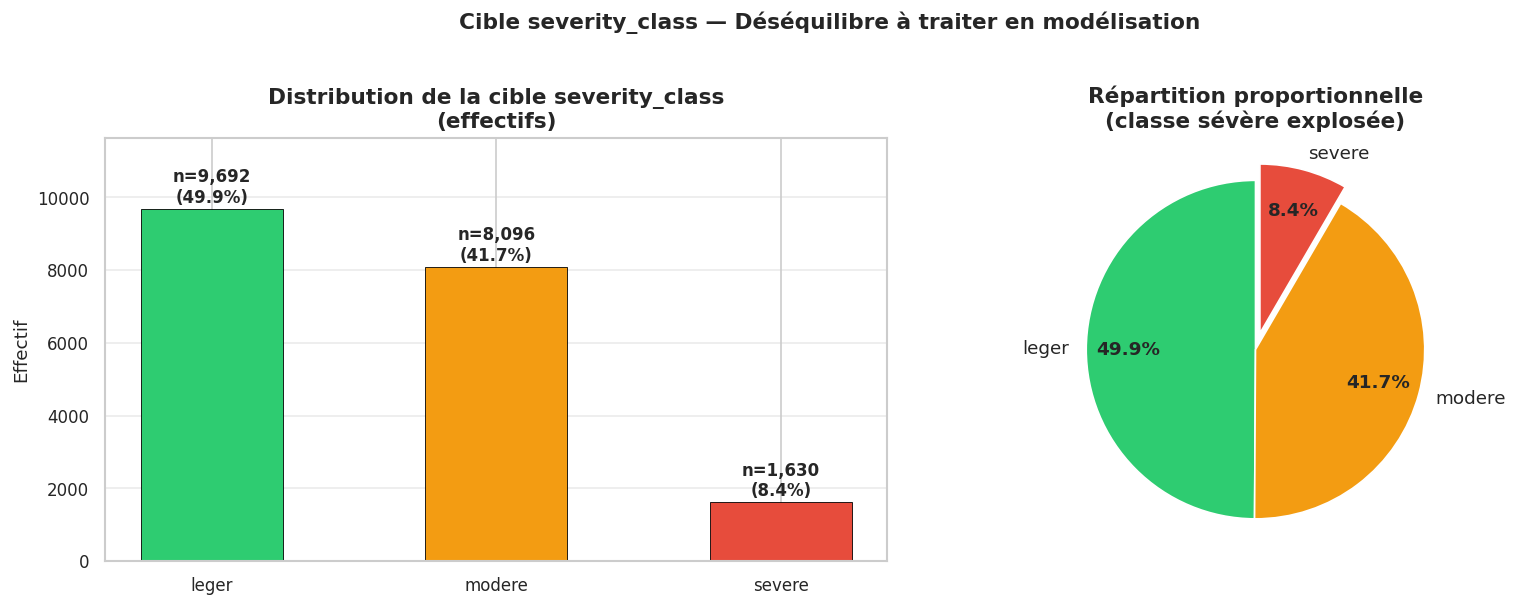

In [22]:
# ============================================================
# 9.2 — Visualisation de la distribution de la cible
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot avec effectifs
order    = ["leger", "modere", "severe"]
colors   = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}
dist_ord = dist.reindex(order)

bars = axes[0].bar(order, [dist_ord.get(k, 0) for k in order],
                   color=[colors[k] for k in order],
                   edgecolor="black", linewidth=0.5, width=0.5)

for bar, cls in zip(bars, order):
    n   = dist_ord.get(cls, 0)
    pct = n / n_calculable * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"n={n:,}\n({pct:.1f}%)", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

axes[0].set_title("Distribution de la cible severity_class\n(effectifs)", fontweight="bold")
axes[0].set_ylabel("Effectif")
axes[0].set_ylim(0, max(dist_ord.values) * 1.2)
axes[0].grid(axis="y", alpha=0.4)

# Camembert
pct_vals = [dist_ord.get(k, 0) / n_calculable * 100 for k in order]
explode  = (0, 0, 0.1)  # mettre "severe" en évidence
wedges, texts, autotexts = axes[1].pie(
    pct_vals, labels=order, colors=[colors[k] for k in order],
    autopct="%1.1f%%", startangle=90, explode=explode,
    textprops={"fontsize": 11}, pctdistance=0.75
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1].set_title("Répartition proportionnelle\n(classe sévère explosée)", fontweight="bold")

plt.suptitle("Cible severity_class — Déséquilibre à traiter en modélisation",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Section 10 — Analyses cliniques croisées

### 10.1 Objectif

Ces analyses croisées permettent de **valider la construction de la cible**  
en vérifiant que les relations attendues cliniquement se retrouvent dans les données.

Si la cible est bien construite :
- les patients TACS doivent être majoritairement `sévère`
- les patients LACS doivent être majoritairement `léger`
- l'âge moyen doit augmenter avec la sévérité
- RCONSC=U doit être quasi exclusivement dans `sévère`


STYPE vs severity_class (% en ligne) :


severity_class,leger,modere,severe
STYPE,,,
TACS,4.500,69.400,26.100
PACS,46.300,51.300,2.400
POCS,51.200,38.400,10.400
LACS,100.000,0.000,0.000
OTH,100.000,0.000,0.000


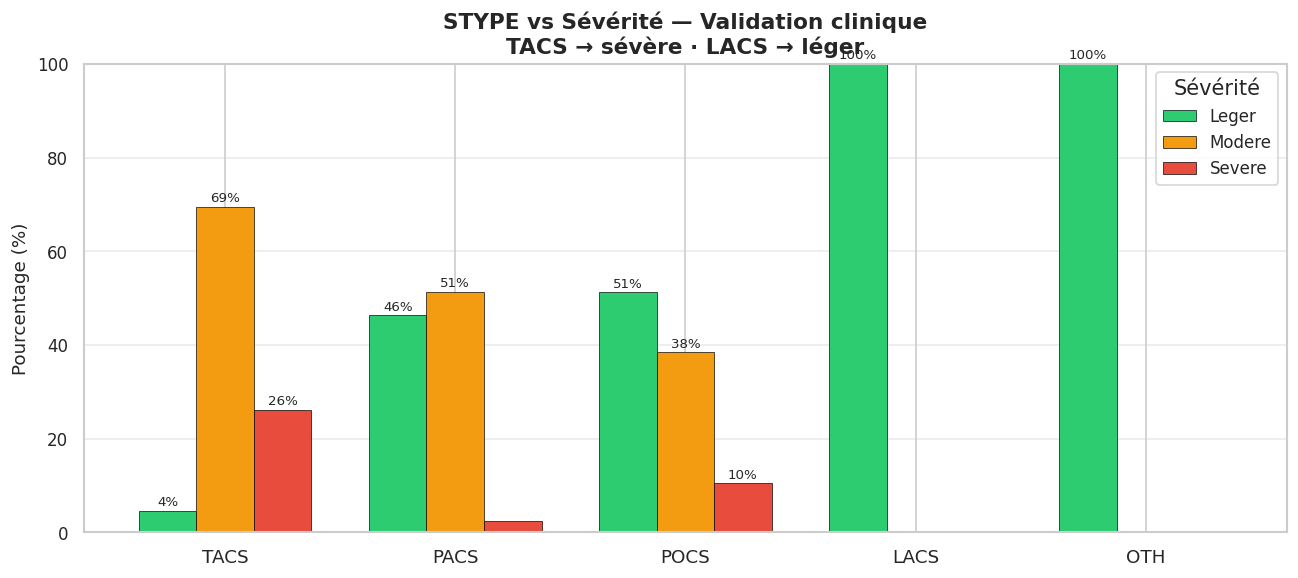

In [23]:
# ============================================================
# 10.1 — STYPE vs severity_class (validation clinique majeure)
# ============================================================

cross_stype = pd.crosstab(
    df["STYPE"], df["severity_class"],
    values=df["STYPE"], aggfunc="count", normalize="index"
) * 100

cross_stype = cross_stype.reindex(columns=["leger", "modere", "severe"]).round(1)
cross_stype = cross_stype.reindex(["TACS", "PACS", "POCS", "LACS", "OTH"])

print("STYPE vs severity_class (% en ligne) :")
display(cross_stype)

# Visualisation
fig, ax = plt.subplots(figsize=(11, 5))
x      = np.arange(len(cross_stype))
w      = 0.25
colors = {"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"}

for i, cls in enumerate(["leger", "modere", "severe"]):
    vals = [cross_stype.loc[st, cls] if st in cross_stype.index else 0
            for st in cross_stype.index]
    bars = ax.bar(x + (i-1)*w, vals, w, label=cls.capitalize(),
                  color=colors[cls], edgecolor="black", lw=0.4)
    for bar, v in zip(bars, vals):
        if v > 3:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f"{v:.0f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cross_stype.index, fontsize=11)
ax.set_ylabel("Pourcentage (%)", fontsize=11)
ax.set_title("STYPE vs Sévérité — Validation clinique\n"
             "TACS → sévère · LACS → léger",
             fontweight="bold", fontsize=13)
ax.legend(title="Sévérité", fontsize=10)
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_stype_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()


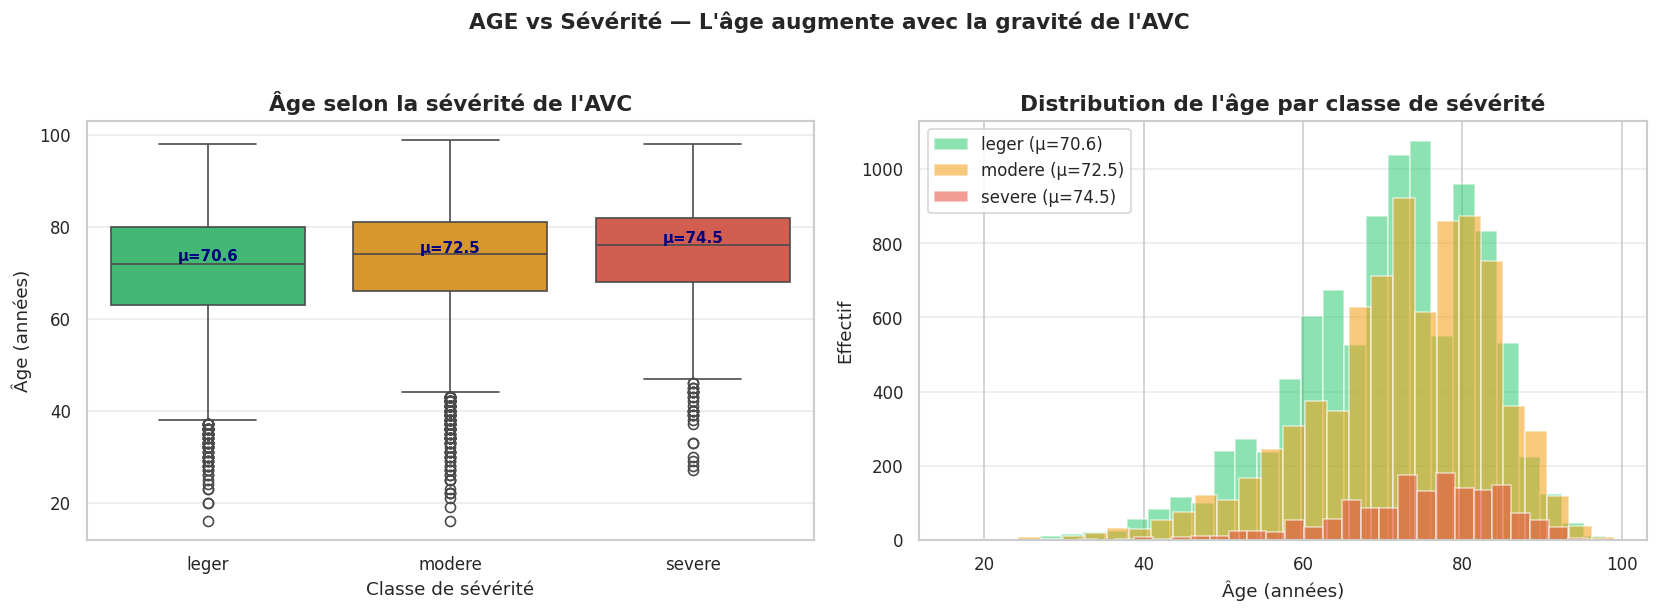

Moyennes d'âge par classe :


,mean,std,count
severity_class,,,
leger,70.610,11.690,9692
modere,72.470,11.570,8096
severe,74.470,10.720,1630


In [24]:
# ============================================================
# 10.2 — AGE vs severity_class
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ["leger", "modere", "severe"]

# Boxplot
sns.boxplot(data=df.dropna(subset=["severity_class"]),
            x="severity_class", y="AGE", order=order,
            palette={"leger": "#2ecc71", "modere": "#f39c12", "severe": "#e74c3c"},
            ax=axes[0])
axes[0].set_title("Âge selon la sévérité de l'AVC", fontweight="bold")
axes[0].set_xlabel("Classe de sévérité")
axes[0].set_ylabel("Âge (années)")
axes[0].grid(axis="y", alpha=0.4)

# Moyennes par classe
age_means = df.groupby("severity_class")["AGE"].agg(["mean", "std", "count"])
age_means = age_means.reindex(order)
for cls, row in age_means.iterrows():
    idx = order.index(cls)
    axes[0].text(idx, row["mean"] + 2,
                 f"μ={row['mean']:.1f}", ha="center", fontsize=9, color="navy", fontweight="bold")

# Distribution superposée
for cls, color in zip(order, ["#2ecc71", "#f39c12", "#e74c3c"]):
    subset = df[df["severity_class"] == cls]["AGE"].dropna()
    axes[1].hist(subset, bins=30, alpha=0.55, color=color,
                 label=f"{cls} (μ={subset.mean():.1f})", edgecolor="white", lw=0.3)

axes[1].set_title("Distribution de l'âge par classe de sévérité", fontweight="bold")
axes[1].set_xlabel("Âge (années)")
axes[1].set_ylabel("Effectif")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.4)

plt.suptitle("AGE vs Sévérité — L'âge augmente avec la gravité de l'AVC",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_age_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Moyennes d'âge par classe :")
display(age_means.round(2))


RCONSC vs severity_class (% en ligne) :


severity_class,leger,modere,severe
RCONSC,,,
D,3.300,63.800,32.900
F,64.000,35.700,0.300
U,0.000,21.100,78.900


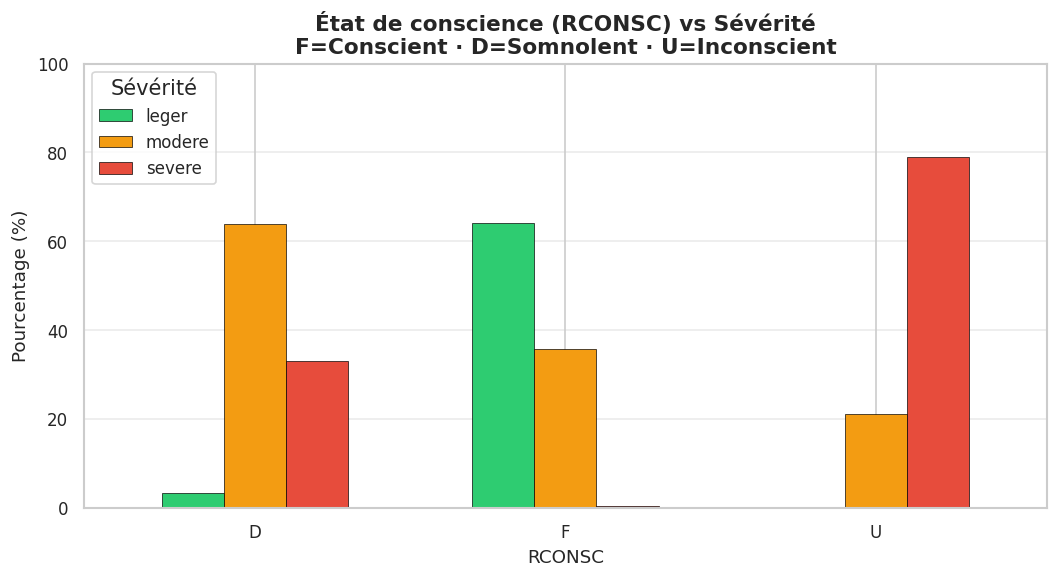


Validation clinique :
  F (conscient)  → sévère ≈ 0.25%    presque jamais sévère
  D (somnolent)  → sévère ≈ 33%      intermédiaire
  U (inconscient)→ sévère ≈ 79%      presque toujours sévère

 Note : RCONSC est dans la formule de severity_score → relation 'mécanique'
   Cette relation disparaît en V2 (RCONSC retiré des features)


In [25]:
# ============================================================
# 10.3 — RCONSC vs severity_class (relation directe — attendue)
# ============================================================

cross_rconsc = pd.crosstab(
    df["RCONSC"], df["severity_class"], normalize="index"
) * 100
cross_rconsc = cross_rconsc.reindex(columns=["leger", "modere", "severe"]).round(1)

print("RCONSC vs severity_class (% en ligne) :")
display(cross_rconsc)

fig, ax = plt.subplots(figsize=(9, 5))
cross_rconsc.plot(kind="bar", ax=ax,
                  color=["#2ecc71", "#f39c12", "#e74c3c"],
                  edgecolor="black", linewidth=0.4, width=0.6)

ax.set_title("État de conscience (RCONSC) vs Sévérité\n"
             "F=Conscient · D=Somnolent · U=Inconscient",
             fontweight="bold", fontsize=13)
ax.set_xlabel("RCONSC", fontsize=11)
ax.set_ylabel("Pourcentage (%)", fontsize=11)
ax.tick_params(axis="x", rotation=0)
ax.set_ylim(0, 100)
ax.legend(title="Sévérité", fontsize=10)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_rconsc_vs_severity.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Validation clinique :")
print("  F (conscient)  → sévère ≈ 0.25%    presque jamais sévère")
print("  D (somnolent)  → sévère ≈ 33%      intermédiaire")
print("  U (inconscient)→ sévère ≈ 79%      presque toujours sévère")
print()
print(" Note : RCONSC est dans la formule de severity_score → relation 'mécanique'")
print("   Cette relation disparaît en V2 (RCONSC retiré des features)")


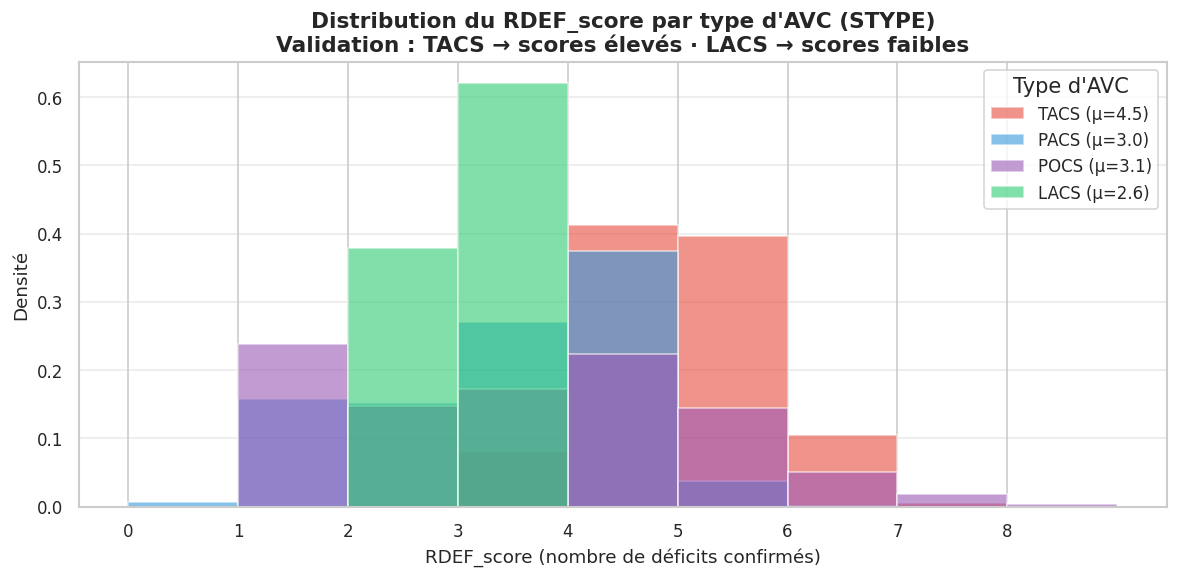

Score moyen RDEF par STYPE :


,mean,median,std,count
STYPE,,,,
TACS,4.540,5.000,0.810,4638
PACS,2.970,3.000,1.170,7838
POCS,3.140,3.000,1.650,2228
LACS,2.620,3.000,0.490,4657


In [26]:
# ============================================================
# 10.4 — STYPE vs RDEF_score — validation croisée clinique
# ============================================================

# Hypothèse : TACS → plus de déficits (RDEF_score élevé)
# LACS → peu de déficits (RDEF_score faible)

fig, ax = plt.subplots(figsize=(10, 5))

stype_order = ["TACS", "PACS", "POCS", "LACS"]
palette_stype = {"TACS": "#e74c3c", "PACS": "#3498db",
                 "POCS": "#9b59b6", "LACS": "#2ecc71"}

for stype in stype_order:
    subset = df[(df["STYPE"] == stype) & df["RDEF_score_v1"].notna()]["RDEF_score_v1"]
    ax.hist(subset, bins=range(0, 10), alpha=0.6, label=f"{stype} (μ={subset.mean():.1f})",
            color=palette_stype[stype], edgecolor="white", lw=0.3, density=True)

ax.set_xlabel("RDEF_score (nombre de déficits confirmés)", fontsize=11)
ax.set_ylabel("Densité", fontsize=11)
ax.set_title("Distribution du RDEF_score par type d'AVC (STYPE)\n"
             "Validation : TACS → scores élevés · LACS → scores faibles",
             fontweight="bold", fontsize=13)
ax.legend(title="Type d'AVC", fontsize=10)
ax.set_xticks(range(0, 9))
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_stype_vs_rdef_score.png", dpi=150, bbox_inches="tight")
plt.show()

print("Score moyen RDEF par STYPE :")
display(df.groupby("STYPE")["RDEF_score_v1"].agg(["mean","median","std","count"]).round(2).reindex(["TACS","PACS","POCS","LACS"]))


---
## Section 11 — Corrélations et redondance entre variables

### 11.1 Objectif

La matrice de corrélation permet de :
- détecter des variables **redondantes** (risque de multicolinéarité),
- identifier des relations **logiques** entre features et outcomes,
- repérer des variables de **leakage** (corrélées à l'outcome futur).

### 11.2 Variables dérivées à surveiller

`EXPDD`, `EXPD6`, `EXPD14` sont des **probabilités prédites** calculées a posteriori  
sur le dataset entier. Elles sont fortement corrélées entre elles **et** avec les outcomes.  
Les inclure comme features reviendrait à injecter une prédiction comme entrée → leakage.


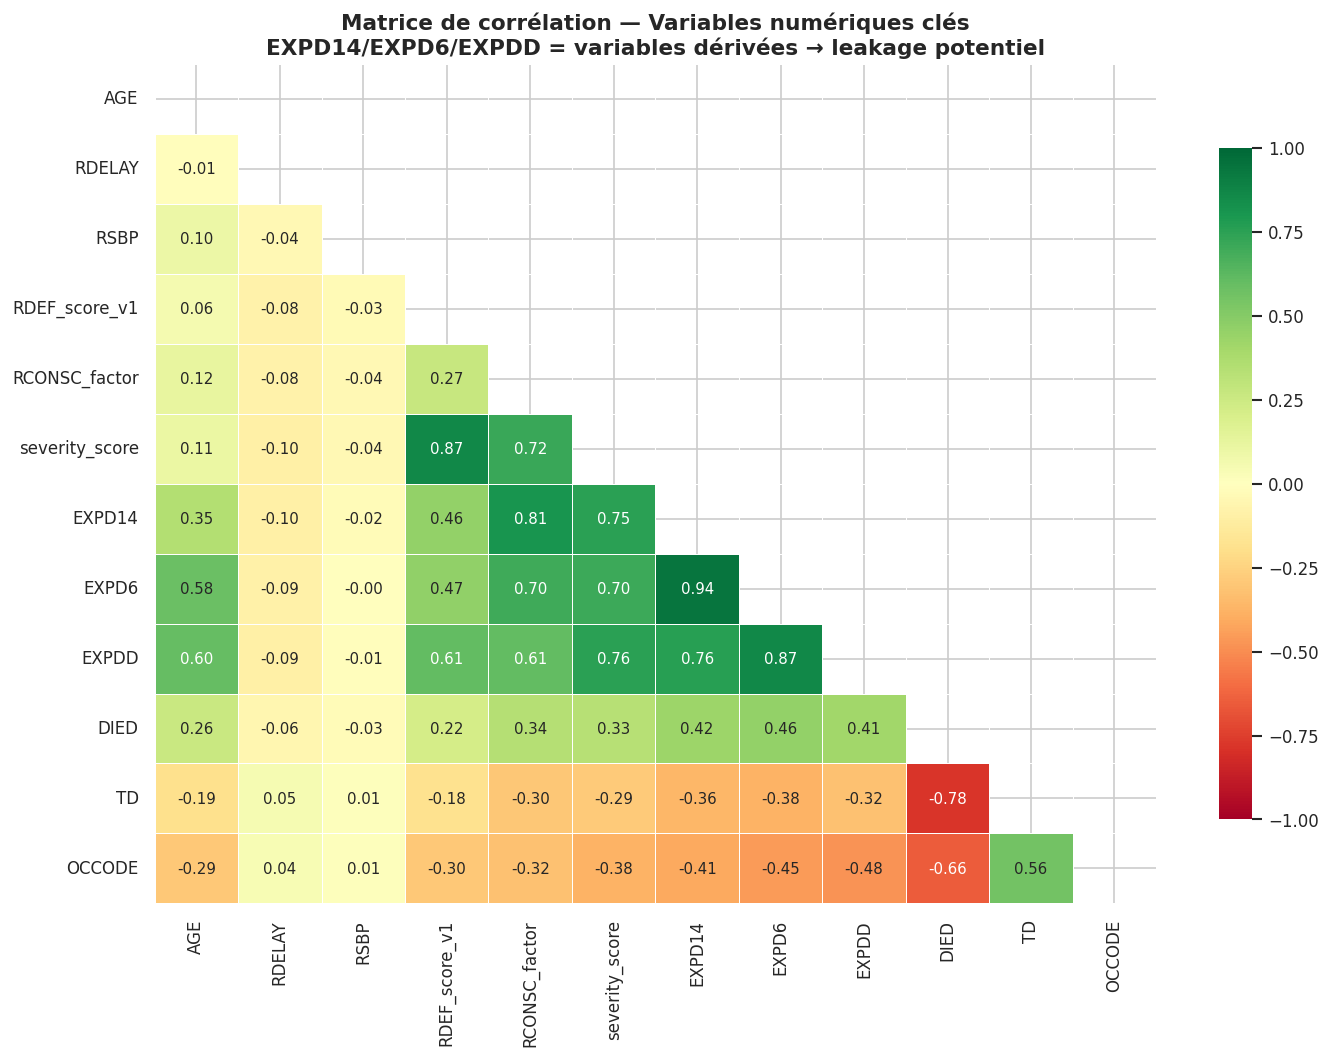

In [27]:
# ============================================================
# 11.1 — Heatmap de corrélation (variables numériques sélectionnées)
# ============================================================

# Sélection de variables numériques pertinentes (baseline + outcomes + dérivées)
corr_subset = [col for col in [
    "AGE", "RDELAY", "RSBP", "RDEF_score_v1", "RCONSC_factor",
    "severity_score", "EXPD14", "EXPD6", "EXPDD",
    "DIED", "TD", "OCCODE"
] if col in df.columns]

corr_matrix = df[corr_subset].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # masque triangle supérieur

sns.heatmap(
    corr_matrix, mask=mask, annot=True, cmap="RdYlGn",
    fmt=".2f", linewidths=0.5, center=0, vmin=-1, vmax=1,
    annot_kws={"size": 9}, ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Matrice de corrélation — Variables numériques clés\n"
             "EXPD14/EXPD6/EXPDD = variables dérivées → leakage potentiel",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()


### 11.2 Interprétation de la matrice de corrélation

**Relations fortes attendues :**
- `EXPD14 ↔ EXPD6 ↔ EXPDD` : corrélation > 0.90 → redondance totale → exclure 2 sur 3
- `severity_score ↔ RDEF_score` : corrélation forte → attendue (RDEF entre dans severity)
- `DIED ↔ OCCODE` : corrélation logique (décès → code fonctionnel le plus sévère)

**Variables indépendantes (faibles corrélations) :**
- `RSBP`, `RDELAY`, `AGE` : peu corrélées entre elles → apportent des informations distinctes

**Conclusion pour la sélection de features :**
- Exclure `EXPDD`, `EXPD6`, `EXPD14` (redondance + leakage)
- Exclure `DIED`, `OCCODE` des features Axe 2 (outcomes → leakage temporel)


---
## Section 12 — Détection et classification du Data Leakage

### 12.1 Les deux types de leakage dans l'IST

**Type 1 — Leakage temporel**  
Utiliser des variables collectées APRÈS le moment de prédiction.  
Pour l'Axe 2 (prédiction à l'admission), toutes les variables T=14j et T=6mois sont interdites.

**Type 2 — Leakage structurel**  
Utiliser des variables qui participent directement à la construction de la cible.  
Pour l'Axe 2, `RCONSC` et `RDEF1..RDEF8` entrent dans la formule de `severity_class`.  
Les inclure dans les features donne des performances quasi-parfaites (>0.99) mais irréalistes.

### 12.2 Règle de décision

```
Variable disponible à T=0 ET n'entre pas dans la formule de la cible → ✅ Features autorisées
Variable disponible à T=0 ET entre dans la formule de la cible       → ⚠️ V1 uniquement (démo leakage)
Variable disponible après T=0                                         → ❌ Exclure absolument
Variable dérivée a posteriori (EXPDD, etc.)                          → ❌ Exclure absolument
```


In [28]:
# ============================================================
# 12.1 — Classification des variables par risque de leakage (Axe 2)
# ============================================================

leakage_classification = {
    " AUTORISÉES — Features sûres (Axe 2)": [
        "AGE", "SEX", "RDELAY", "RSBP", "RSLEEP",
        "RATRIAL", "RCT", "RVISINF", "RHEP24", "RASP3", "STYPE"
    ],
    " LEAKAGE STRUCTUREL — Dans formule cible (exclure en V2)": [
        "RCONSC", "RDEF1", "RDEF2", "RDEF3", "RDEF4",
        "RDEF5", "RDEF6", "RDEF7", "RDEF8"
    ],
    " LEAKAGE TEMPOREL — Outcomes 14j (interdites Axe 2)": [
        "DDEAD", "DDEADD", "DRSISC", "DRSH", "DMAJNCH",
        "DPLACE", "DALIVE", "DPE", "ID14"
    ],
    " LEAKAGE TEMPOREL — Outcomes 6 mois (interdites Axe 2)": [
        "FDEAD", "FRECOVER", "FDENNIS", "OCCODE",
        "FPLACE", "FAP", "FOAC"
    ],
    " VARIABLES DÉRIVÉES — Leakage potentiel (interdites tous axes)": [
        "EXPDD", "EXPD6", "EXPD14", "DIED", "TD",
        "SET14D", "H14", "ISC14", "NK14", "STRK14"
    ]
}

print("Classification des variables par risque de Data Leakage (Axe 2) :")
print("=" * 70)
for categorie, variables in leakage_classification.items():
    present = [v for v in variables if v in df.columns]
    print(f"\n{categorie}")
    print(f"  Variables : {present}")


Classification des variables par risque de Data Leakage (Axe 2) :

 AUTORISÉES — Features sûres (Axe 2)
  Variables : ['AGE', 'SEX', 'RDELAY', 'RSBP', 'RSLEEP', 'RATRIAL', 'RCT', 'RVISINF', 'RHEP24', 'RASP3', 'STYPE']

 LEAKAGE STRUCTUREL — Dans formule cible (exclure en V2)
  Variables : ['RCONSC', 'RDEF1', 'RDEF2', 'RDEF3', 'RDEF4', 'RDEF5', 'RDEF6', 'RDEF7', 'RDEF8']

 LEAKAGE TEMPOREL — Outcomes 14j (interdites Axe 2)
  Variables : ['DDEAD', 'DDEADD', 'DRSISC', 'DRSH', 'DMAJNCH', 'DPLACE', 'DALIVE', 'DPE', 'ID14']

 LEAKAGE TEMPOREL — Outcomes 6 mois (interdites Axe 2)
  Variables : ['FDEAD', 'FRECOVER', 'FDENNIS', 'OCCODE', 'FPLACE', 'FAP', 'FOAC']

 VARIABLES DÉRIVÉES — Leakage potentiel (interdites tous axes)
  Variables : ['EXPDD', 'EXPD6', 'EXPD14', 'DIED', 'TD', 'SET14D', 'H14', 'ISC14', 'NK14', 'STRK14']


---
## Section 13 — Sauvegarde de `features.json` — Pont vers le notebook 02

### 13.1 Pourquoi sauvegarder les variables sélectionnées ?

Le notebook 02 (Preprocessing) doit utiliser **exactement les mêmes variables**  
que celles identifiées et validées ici en EDA.

Sans ce fichier de sauvegarde, il faudrait redéfinir la liste à la main dans chaque notebook,  
avec le risque d'incohérences (oubli d'une variable, faute de frappe, etc.).

`features.json` contient :
- la variable cible (`severity_class`)
- la liste des variables catégorielles
- la liste des variables numériques
- la liste complète des features baseline sélectionnées

### 13.2 Ce que fait `save_features()` de `config.py`

```python
def save_features(target, cat_vars, num_vars, all_features):
    data = {
        "target"    : target,
        "cat_vars"  : cat_vars,
        "num_vars"  : num_vars,
        "all_features": all_features
    }
    with open(ARTIFACTS_DIR / "features.json", "w") as f:
        json.dump(data, f, indent=2)
```


In [29]:
# ============================================================
# 13.1 — Définition finale des features baseline (Axe 2)
# ============================================================

# Variables numériques disponibles à l'admission (Axe 2)
NUMERICAL_VARS = ["RDELAY", "AGE", "RSBP"]

# Variables catégorielles disponibles à l'admission (Axe 2)
CATEGORICAL_VARS = [
    "RCONSC",                                           # état de conscience (leakage structurel V1)
    "SEX", "RSLEEP", "RATRIAL", "RCT", "RVISINF",      # variables cliniques générales
    "RHEP24", "RASP3",                                  # traitements antérieurs
    "RDEF1", "RDEF2", "RDEF3", "RDEF4",               # déficits neurologiques (leakage structurel V1)
    "RDEF5", "RDEF6", "RDEF7", "RDEF8",
    "STYPE"                                             # type d'AVC
]

# Liste complète (utilisée dans le preprocessing)
ALL_FEATURES = NUMERICAL_VARS + CATEGORICAL_VARS

# Vérification : toutes ces variables sont bien dans le dataset ?
missing_from_df = [col for col in ALL_FEATURES if col not in df.columns]
print("Variables sélectionnées pour l'Axe 2 :")
print(f"  Numériques ({len(NUMERICAL_VARS)})   : {NUMERICAL_VARS}")
print(f"  Catégorielles ({len(CATEGORICAL_VARS)}) : {CATEGORICAL_VARS}")
print(f"  Total ({len(ALL_FEATURES)})")
print()
if missing_from_df:
    print(f"Variables absentes du dataset : {missing_from_df}")
else:
    print("Toutes les variables sont présentes dans le dataset")


Variables sélectionnées pour l'Axe 2 :
  Numériques (3)   : ['RDELAY', 'AGE', 'RSBP']
  Catégorielles (17) : ['RCONSC', 'SEX', 'RSLEEP', 'RATRIAL', 'RCT', 'RVISINF', 'RHEP24', 'RASP3', 'RDEF1', 'RDEF2', 'RDEF3', 'RDEF4', 'RDEF5', 'RDEF6', 'RDEF7', 'RDEF8', 'STYPE']
  Total (20)

Toutes les variables sont présentes dans le dataset


In [30]:
# ============================================================
# 13.2 — Sauvegarde features.json — Pont vers notebook 02
# ============================================================

import json

features_eda = {
    "target"      : "severity_class",
    "num_vars"    : NUMERICAL_VARS,
    "cat_vars"    : CATEGORICAL_VARS,
    "all_features": ALL_FEATURES,
    "n_features"  : len(ALL_FEATURES),
}

features_path = ARTIFACTS_DIR / "axe2" / "features_eda.json"
features_path.parent.mkdir(parents=True, exist_ok=True)

with open(features_path, "w") as f:
    json.dump(features_eda, f, indent=2)

print("features_eda.json sauvegarde : " + str(features_path))
print()
print("  Cible           : " + features_eda["target"])
print("  Nb num_vars     : " + str(len(NUMERICAL_VARS)))
print("  Nb cat_vars     : " + str(len(CATEGORICAL_VARS)))
print("  Nb all_features : " + str(len(ALL_FEATURES)))
print()
print("Ce fichier sera lu par le notebook 02 (Preprocessing)")

features_eda.json sauvegarde : /content/drive/MyDrive/ML_Project/artifacts/axe2/features_eda.json

  Cible           : severity_class
  Nb num_vars     : 3
  Nb cat_vars     : 17
  Nb all_features : 20

Ce fichier sera lu par le notebook 02 (Preprocessing)


---
## Section 14 — Synthèse et recommandations pour le Preprocessing

### 14.1 Ce que l'EDA a révélé

| Dimension | Observation | Impact |
|-----------|-------------|--------|
| **Structure** | 19 435 patients · 112 colonnes · 3 temps de collecte | Pipeline anti-leakage obligatoire |
| **Complétude** | Baseline quasi-complète · NaN structurels dans les outcomes | Imputation légère sur RATRIAL/RASP3 |
| **Doublons** | 0 doublon exact | Dataset intègre |
| **RSBP=0** | Quelques cas · erreur de saisie | Remplacer par NaN avant imputation |
| **RDEF "C"** | Information clinique (patient non évaluable) | Ne pas traiter comme NaN naïvement |
| **Cible** | léger 50% · modéré 42% · sévère **8%** | Déséquilibre → class_weight ou SMOTE |
| **STYPE** | Prédicteur clinique majeur de la sévérité | Inclure dans toutes les versions |
| **EXPDD/EXPD6** | Fortement corrélées entre elles + avec outcomes | Exclure de toutes les features |

### 14.2 Recommandations pour le notebook 02 (Preprocessing)

**Traitement des features numériques :**
1. `RSBP = 0` → remplacer par NaN avant imputation (correction V2)
2. Imputation par **médiane** (robuste aux valeurs extrêmes de l'âge et de la tension)
3. Ajouter `StandardScaler` pour les modèles linéaires (correction V2)

**Traitement des features catégorielles :**
1. `RATRIAL`, `RASP3`, `RHEP24` : imputation par **mode** (modalité la plus fréquente)
2. `RCONSC` : encodage **ordinal** (F=0, D=1, U=2) — ordre médical naturel
3. `RDEF1..8` : traitement des "C" à améliorer en V2 (0.5 + indicateur `_uncertain`)
4. `STYPE` : `OneHotEncoder` (5 modalités sans ordre naturel)

**Gestion du déséquilibre (sévère = 8%) :**
- V1 : `class_weight='balanced'` dans tous les modèles
- V2 : `SMOTE` appliqué **uniquement sur X_train** après le split

**Pipeline à construire :**
```
ColumnTransformer
├── Numérique : SimpleImputer(médiane) [+ StandardScaler en V2]
└── Catégoriel: SimpleImputer(mode) → OneHotEncoder
```

### 14.3 Questions cliniques validées

✅ L'âge augmente avec la sévérité de l'AVC  
✅ TACS → majoritairement sévère · LACS → majoritairement léger  
✅ RCONSC=U → 79% de cas sévères · RCONSC=F → 0.25% seulement  
✅ RDEF_score augmente avec STYPE (TACS > PACS > POCS > LACS)  
✅ La cible `severity_class` est construisible sur 19 418/19 435 patients (99.9%)

---

> **Ce notebook est complet.**  
> Le fichier `features.json` est sauvegardé dans `artifacts/`.  
> Passer au notebook `02_Preprocessing_V1.ipynb`.
